In [1]:
%pip install numpy pandas matplotlib

  Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cach

# Exercise A - Placement and Simulated Annealing
## A.1

Exercise A.1 - Running default parameters for all circuits
Running sha...
Running raygentop...
Running or1200...
Running boundtop...
All circuits completed!

Results Summary:
------------------------------------------------------------
sha          | Initial:   231.71 | Final:   143.57 | Improvement:  38.0%
raygentop    | Initial:   349.43 | Final:   192.11 | Improvement:  45.0%
or1200       | Initial:   606.75 | Final:   345.02 | Improvement:  43.1%
boundtop     | Initial:   415.38 | Final:   199.70 | Improvement:  51.9%


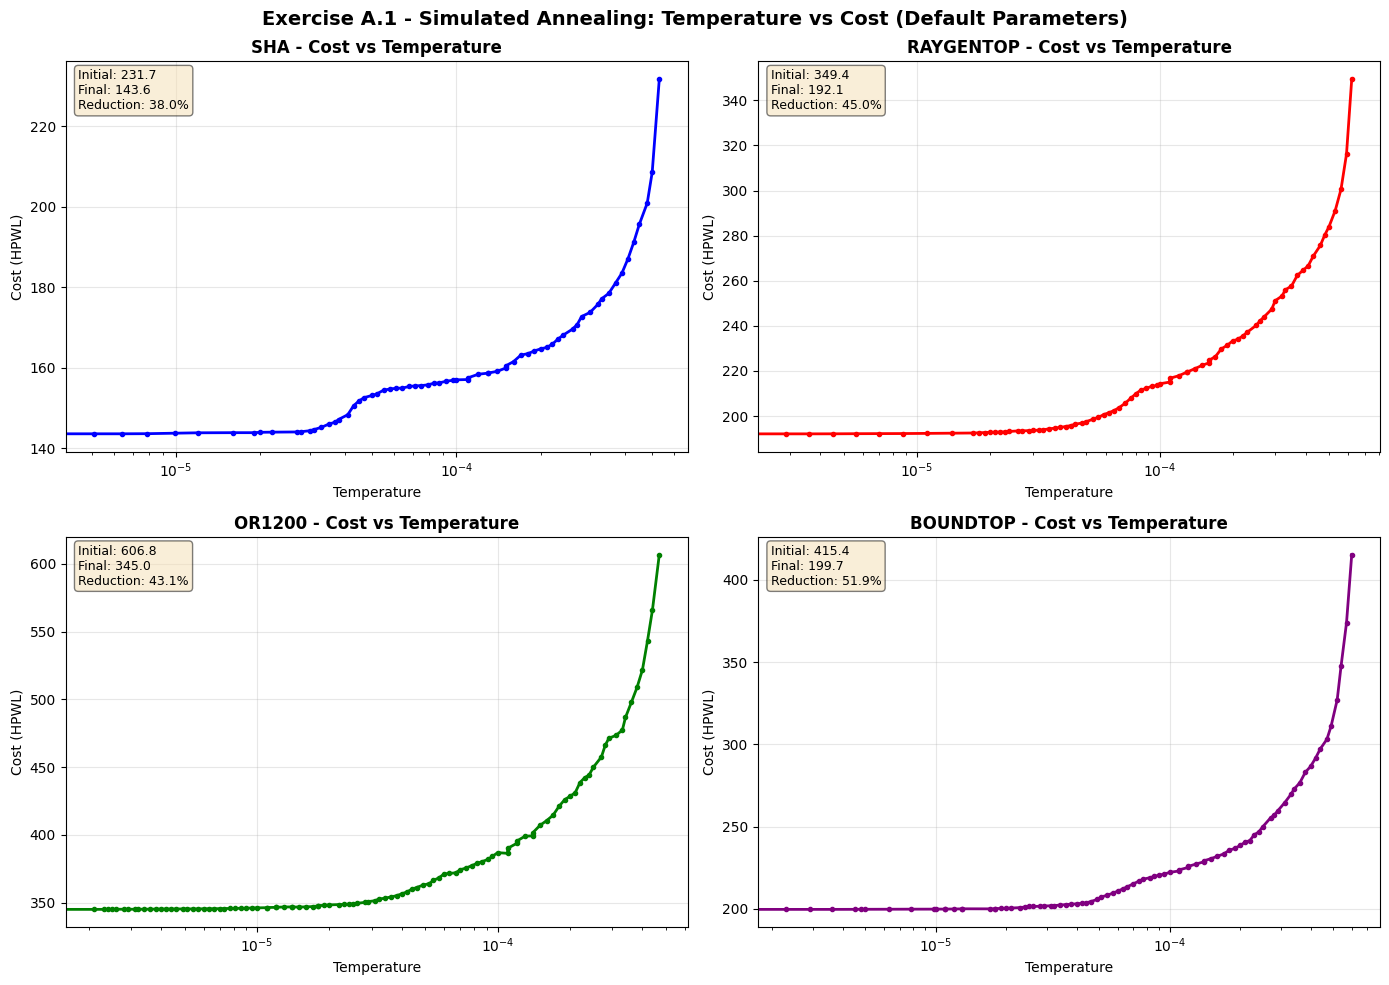


✓ Exercise A.1 complete!


In [12]:
import subprocess
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import re

# Create directory for A.1 logs
os.makedirs('a1_logs', exist_ok=True)

# Define circuits
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']

print("Exercise A.1 - Running default parameters for all circuits")
print("="*60)

# Run VPR for each circuit with default parameters
for circuit in circuits:
    print(f"Running {circuit}...")
    
    cmd = [
        "./vtr-verilog-to-routing/vpr/vpr",
        "k6_N10_mem32K_40nm.xml",
        f"{circuit}.blif",
        "--pack", "--place",
        "--place_algorithm", "bounding_box"
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"  ERROR running VPR for {circuit}")
        continue
    
    # Move VPR-generated files to logs directory
    files_to_move = {
        'vpr_stdout.log': f"{circuit}_default.log",
        f'{circuit}.net': f'{circuit}.net',
        f'{circuit}.place': f'{circuit}.place',
        f'{circuit}.route': f'{circuit}.route',
        'packing_pin_util.rpt': f'{circuit}_packing_pin_util.rpt',
        'pre_pack.report_timing.setup.rpt': f'{circuit}_pre_pack.report_timing.setup.rpt',
    }
    
    for source_file, dest_name in files_to_move.items():
        if os.path.exists(source_file):
            shutil.move(source_file, f"a1_logs/{dest_name}")

print("All circuits completed!\n")

# Function to extract temperature and cost data
def extract_annealing_data(log_file):
    """Extract temperature and cost data from VPR log file."""
    temperatures = []
    costs = []
    
    with open(log_file, 'r') as f:
        for line in f:
            match = re.match(r'^\s+(\d+)\s+([\d.e+-]+)\s+([\d.e+-]+)\s+([\d.e+-]+)\s+([\d.e+-]+)', line)
            if match:
                try:
                    temp = float(match.group(3))
                    cost = float(match.group(5))
                    temperatures.append(temp)
                    costs.append(cost)
                except (ValueError, IndexError):
                    continue
                        
    return temperatures, costs

# Extract and display results
print("Results Summary:")
print("-"*60)
for circuit in circuits:
    log_file = f"a1_logs/{circuit}_default.log"
    temps, costs = extract_annealing_data(log_file)
    if costs:
        improvement = ((costs[0]-costs[-1])/costs[0]*100)
        print(f"{circuit:12s} | Initial: {costs[0]:8.2f} | Final: {costs[-1]:8.2f} | Improvement: {improvement:5.1f}%")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['blue', 'red', 'green', 'purple']

for idx, circuit in enumerate(circuits):
    log_file = f"a1_logs/{circuit}_default.log"
    temps, costs = extract_annealing_data(log_file)
    
    ax = axes[idx]
    
    if temps and costs:
        ax.plot(temps, costs, color=colors[idx], linewidth=2, marker='o', markersize=3)
        ax.set_xlabel('Temperature', fontsize=10)
        ax.set_ylabel('Cost (HPWL)', fontsize=10)
        ax.set_title(f'{circuit.upper()} - Cost vs Temperature', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        
        textstr = (f'Initial: {costs[0]:.1f}\n'
                   f'Final: {costs[-1]:.1f}\n'
                   f'Reduction: {((costs[0]-costs[-1])/costs[0]*100):.1f}%')
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Exercise A.1 - Simulated Annealing: Temperature vs Cost (Default Parameters)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('a1_logs/a1_individual_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Exercise A.1 complete!")

## A.2 

Exercise A.2 - Running with different random seeds

Processing sha...
  Running seed 1... Cost: 143.57
  Running seed 42... Cost: 143.20
  Running seed 100... Cost: 144.66
  Running seed 500... Cost: 137.51
  Running seed 1000... Cost: 147.73

  SHA Statistics:
    Mean Cost: 143.33
    Std Dev: 3.71
    Coeff. of Variation: 2.59%
    Min: 137.51, Max: 147.73
    Range: 10.22

Processing raygentop...
  Running seed 1... Cost: 192.10
  Running seed 42... Cost: 195.84
  Running seed 100... Cost: 193.67
  Running seed 500... Cost: 187.75
  Running seed 1000... Cost: 194.87

  RAYGENTOP Statistics:
    Mean Cost: 192.85
    Std Dev: 3.17
    Coeff. of Variation: 1.64%
    Min: 187.75, Max: 195.84
    Range: 8.08

Processing or1200...
  Running seed 1... Cost: 345.01
  Running seed 42... Cost: 339.58
  Running seed 100... Cost: 342.76
  Running seed 500... Cost: 341.28
  Running seed 1000... Cost: 346.46

  OR1200 Statistics:
    Mean Cost: 343.02
    Std Dev: 2.77
    Coeff. of Variation: 

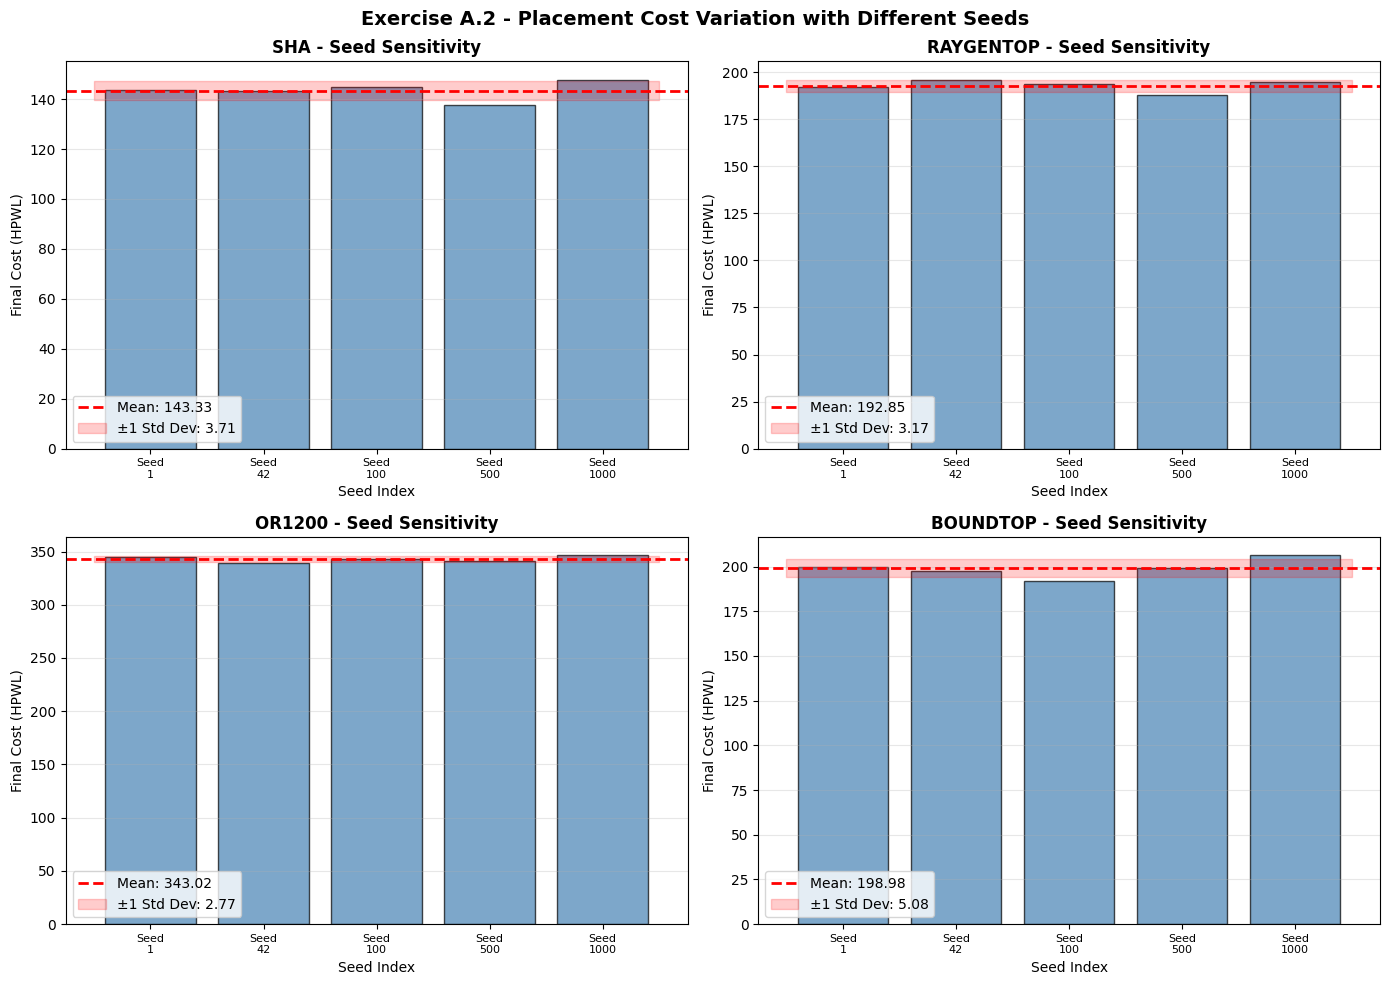


Summary Table - Exercise A.2
Circuit      Mean       Std Dev    CV (%)     Min        Max       
--------------------------------------------------------------------------------
sha          143.33     3.71       2.59       137.51     147.73    
raygentop    192.85     3.17       1.64       187.75     195.84    
or1200       343.02     2.77       0.81       339.58     346.46    
boundtop     198.98     5.08       2.55       192.12     206.28    

Commentary - Sensitivity to Random Seed:
--------------------------------------------------------------------------------
SHA         : low (stable) - CV = 2.59%
RAYGENTOP   : low (stable) - CV = 1.64%
OR1200      : very low (highly stable) - CV = 0.81%
BOUNDTOP    : low (stable) - CV = 2.55%

✓ Exercise A.2 complete!


In [14]:
import subprocess
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Create directory for A.2 logs
os.makedirs('a2_logs', exist_ok=True)

# Define circuits and seeds
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
seeds = [1, 42, 100, 500, 1000]  # 5 different seeds

print("Exercise A.2 - Running with different random seeds")
print("="*60)

def extract_final_cost(log_file):
    """
    Extract final placement cost from VPR log.
    Looking for the bb_cost (bounding box cost = HPWL) in the final placement cost line.
    """
    with open(log_file, 'r') as f:
        content = f.read()
        
        # Look for final placement cost line
        # Format: "Placement cost: 0.999872, bb_cost: 143.573, td_cost: nan,"
        matches = re.findall(r'bb_cost:\s*([\d.]+)', content)
        if matches:
            # Return the last bb_cost found (final cost)
            return float(matches[-1])
    
    return None

# Store results
results = {}

for circuit in circuits:
    print(f"\nProcessing {circuit}...")
    costs = []
    
    for seed in seeds:
        print(f"  Running seed {seed}...", end=" ")
        
        # Run VPR command
        cmd = [
            "./vtr-verilog-to-routing/vpr/vpr",
            "k6_N10_mem32K_40nm.xml",
            f"{circuit}.blif",
            "--pack", "--place",
            "--place_algorithm", "bounding_box",
            "--seed", str(seed)
        ]
        
        # Run and capture output
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            print("ERROR")
            continue
        
        # Save log file
        log_file = f"a2_logs/{circuit}_seed{seed}.log"
        with open(log_file, 'w') as f:
            f.write(result.stdout)
        
        # Extract cost
        cost = extract_final_cost(log_file)
        if cost:
            costs.append(cost)
            print(f"Cost: {cost:.2f}")
        else:
            print("Failed to extract cost")
        
        # Clean up generated files
        for ext in ['.net', '.place', '.route']:
            filename = f"{circuit}{ext}"
            if os.path.exists(filename):
                os.remove(filename)
        
        for file in ['packing_pin_util.rpt', 'pre_pack.report_timing.setup.rpt']:
            if os.path.exists(file):
                os.remove(file)
    
    results[circuit] = costs
    
    # Calculate statistics
    if costs:
        mean_cost = np.mean(costs)
        std_cost = np.std(costs, ddof=1)  # Sample std dev
        cv = (std_cost / mean_cost) * 100  # Coefficient of variation
        
        print(f"\n  {circuit.upper()} Statistics:")
        print(f"    Mean Cost: {mean_cost:.2f}")
        print(f"    Std Dev: {std_cost:.2f}")
        print(f"    Coeff. of Variation: {cv:.2f}%")
        print(f"    Min: {min(costs):.2f}, Max: {max(costs):.2f}")
        print(f"    Range: {max(costs) - min(costs):.2f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, circuit in enumerate(circuits):
    if circuit in results and results[circuit]:
        ax = axes[idx]
        costs = results[circuit]
        
        # Plot individual runs
        ax.bar(range(len(costs)), costs, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Add mean line
        mean_cost = np.mean(costs)
        ax.axhline(y=mean_cost, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_cost:.2f}')
        
        # Add std dev band
        std_cost = np.std(costs, ddof=1)
        ax.fill_between([-0.5, len(costs)-0.5], 
                        mean_cost - std_cost, mean_cost + std_cost,
                        alpha=0.2, color='red', label=f'±1 Std Dev: {std_cost:.2f}')
        
        ax.set_xlabel('Seed Index', fontsize=10)
        ax.set_ylabel('Final Cost (HPWL)', fontsize=10)
        ax.set_title(f'{circuit.upper()} - Seed Sensitivity', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(costs)))
        ax.set_xticklabels([f'Seed\n{seeds[i]}' for i in range(len(costs))], fontsize=8)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Exercise A.2 - Placement Cost Variation with Different Seeds', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('a2_logs/exercise_a2_seed_variation.png', dpi=300, bbox_inches='tight')
plt.show()

# Create summary table
print("\n" + "="*80)
print("Summary Table - Exercise A.2")
print("="*80)
print(f"{'Circuit':<12} {'Mean':<10} {'Std Dev':<10} {'CV (%)':<10} {'Min':<10} {'Max':<10}")
print("-"*80)
for circuit in circuits:
    if circuit in results and results[circuit]:
        costs = results[circuit]
        mean_c = np.mean(costs)
        std_c = np.std(costs, ddof=1)
        cv = (std_c / mean_c) * 100
        print(f"{circuit:<12} {mean_c:<10.2f} {std_c:<10.2f} {cv:<10.2f} "
              f"{min(costs):<10.2f} {max(costs):<10.2f}")

# Commentary on sensitivity
print("\n" + "="*80)
print("Commentary - Sensitivity to Random Seed:")
print("-"*80)
for circuit in circuits:
    if circuit in results and results[circuit]:
        costs = results[circuit]
        cv = (np.std(costs, ddof=1) / np.mean(costs)) * 100
        
        if cv < 1:
            sensitivity = "very low (highly stable)"
        elif cv < 3:
            sensitivity = "low (stable)"
        elif cv < 5:
            sensitivity = "moderate"
        else:
            sensitivity = "high (unstable)"
        
        print(f"{circuit.upper():12s}: {sensitivity} - CV = {cv:.2f}%")

print("\n✓ Exercise A.2 complete!")

1. Sensitivity to random seeds?"
   - Circuits with CV < 5%: Low sensitivity
   - Circuits with CV 5-10%: Moderate sensitivity
   - Circuits with CV > 10%: High sensitivity
2. Do all circuits exhibit the same sensitivity?
   - No but they are fairly similar and all show low sensitivity to random seeds.

## A.3

Exercise A.3 - Testing Different Starting Temperatures
Temperature range: 100.0 to 1e-06
Exit temperature: 1e-07
Total runs: 4 × 5 × 5 = 100

SHA:
  Temp 100.000000: ..... → Mean:  147.90, Std:  6.74
  Temp   1.000000: ..... → Mean:  143.29, Std:  2.52
  Temp   0.010000: ..... → Mean:  145.57, Std:  4.45
  Temp   0.000100: ..... → Mean:  159.65, Std:  3.45
  Temp   0.000001: ..... → Mean:  168.50, Std:  4.10

RAYGENTOP:
  Temp 100.000000: ..... → Mean:  200.39, Std:  2.15
  Temp   1.000000: ..... → Mean:  200.66, Std:  4.19
  Temp   0.010000: ..... → Mean:  202.38, Std:  3.01
  Temp   0.000100: ..... → Mean:  216.47, Std:  4.67
  Temp   0.000001: ..... → Mean:  229.04, Std:  4.38

OR1200:
  Temp 100.000000: ..... → Mean:  360.89, Std:  3.60
  Temp   1.000000: ..... → Mean:  359.41, Std:  5.87
  Temp   0.010000: ..... → Mean:  362.11, Std:  3.78
  Temp   0.000100: ..... → Mean:  378.86, Std:  7.26
  Temp   0.000001: ..... → Mean:  401.93, Std:  7.86

BOUNDTOP:
  Temp 100.000000: ..... →

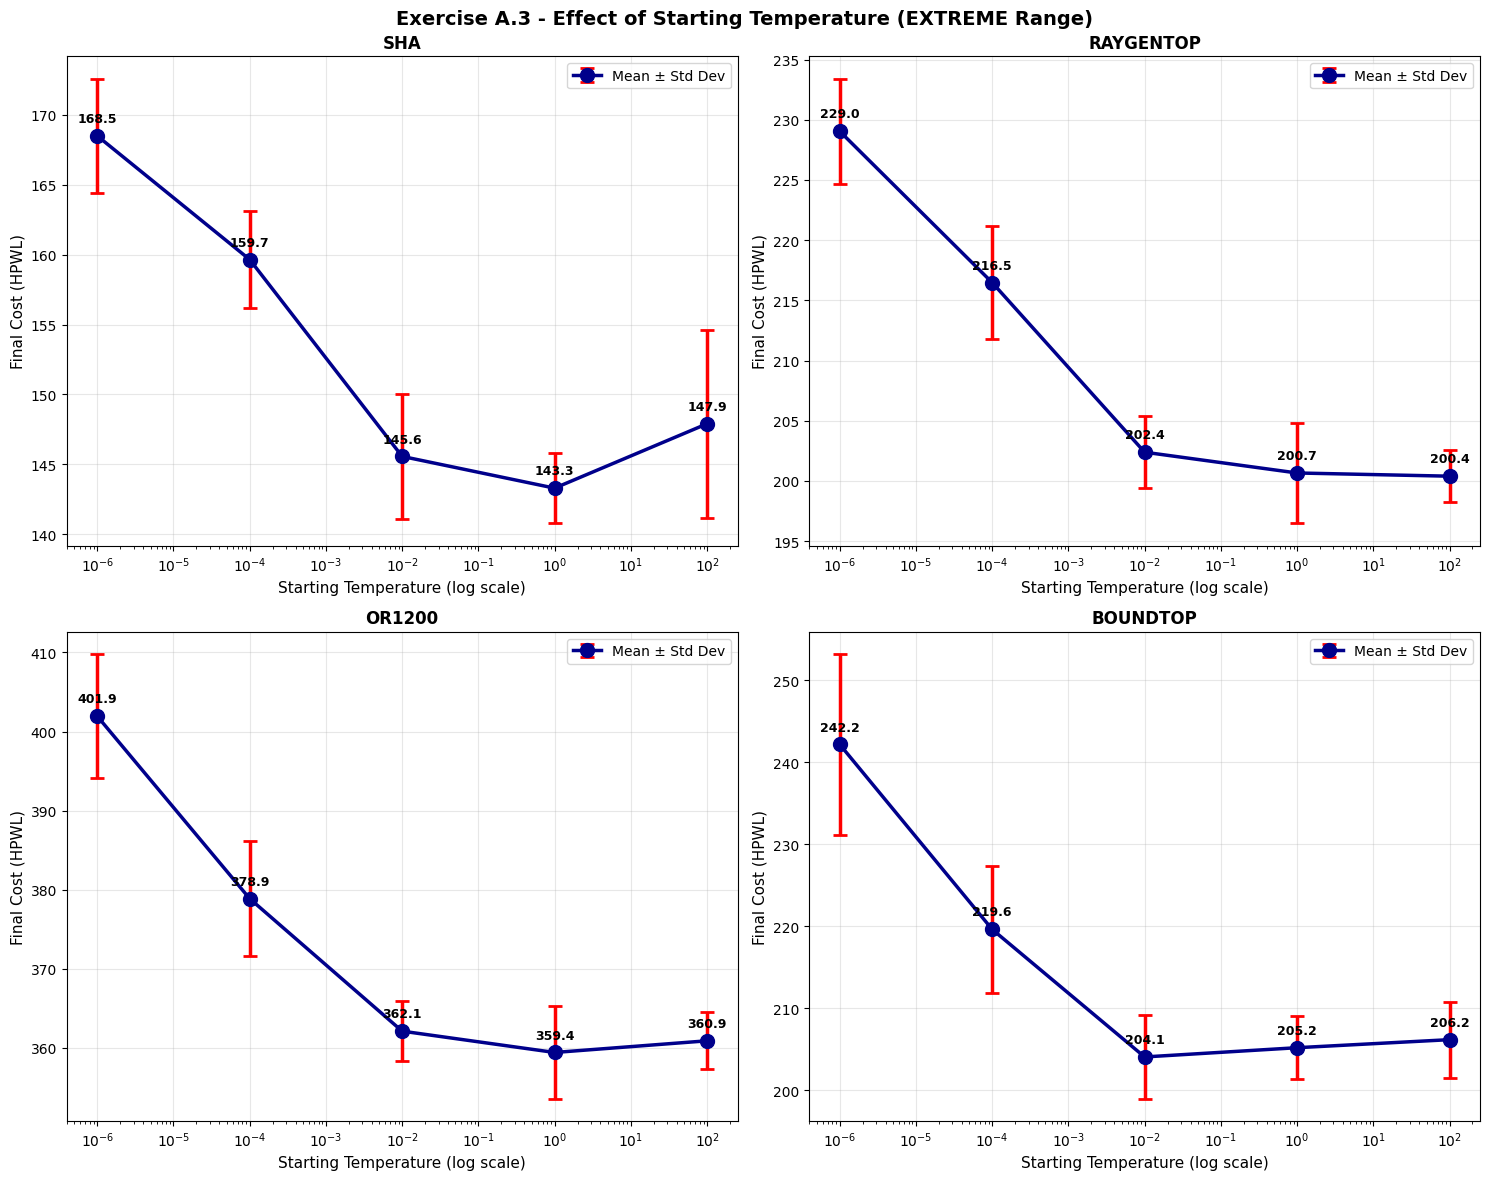


RESULTS TABLE - Exercise A.3
Circuit      Temperature     Mean Cost    Std Dev      CV (%)    
-------------------------------------------------------------------------------------
sha          100.000000      147.90       6.74         4.56      
             1.000000        143.29       2.52         1.76      
             0.010000        145.57       4.45         3.06      
             0.000100        159.65       3.45         2.16      
             0.000001        168.50       4.10         2.43      
-------------------------------------------------------------------------------------
raygentop    100.000000      200.39       2.15         1.07      
             1.000000        200.66       4.19         2.09      
             0.010000        202.38       3.01         1.49      
             0.000100        216.47       4.67         2.16      
             0.000001        229.04       4.38         1.91      
------------------------------------------------------------------------

In [20]:
import subprocess
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import re

# Create logs directory
os.makedirs('a3_logs', exist_ok=True)

def run_vpr_with_temp(circuit, seed, init_temp, exit_temp=None):
    """
    Run VPR with specific seed and temperature settings.
    """
    cmd = [
        "./vtr-verilog-to-routing/vpr/vpr",
        "k6_N10_mem32K_40nm.xml",
        f"{circuit}.blif",
        "--pack", "--place",
        "--place_algorithm", "bounding_box",
        "--seed", str(seed),
        "--init_t", str(init_temp)
    ]
    
    # Add exit temperature if specified
    if exit_temp is not None:
        cmd.extend(["--exit_t", str(exit_temp)])
    
    # Run VPR and capture output
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    # Save log
    log_file = f"a3_logs/{circuit}_seed{seed}_temp{init_temp:.6f}.log"
    with open(log_file, 'w') as f:
        f.write(result.stdout)
    
    return log_file, result.returncode

def extract_final_cost(log_file):
    """Extract final placement cost from VPR log."""
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            matches = re.findall(r'bb_cost:\s*([\d.]+)', content)
            if matches:
                return float(matches[-1])
    except:
        return None
    return None

def cleanup_files(circuit):
    """Clean up generated files after each run."""
    for ext in ['.net', '.place', '.route']:
        filename = f"{circuit}{ext}"
        if os.path.exists(filename):
            os.remove(filename)
    
    for file in ['packing_pin_util.rpt', 'pre_pack.report_timing.setup.rpt']:
        if os.path.exists(file):
            os.remove(file)

# Setup for Exercise A.3
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
seeds = [1, 42, 100, 500, 1000]  # 5 different seeds

# EXTREME temperature range to see actual impact
# Going from very high (almost random) to very low (almost greedy)
temperatures = [
    100.0,      # Very high - almost random placement
    1.0,        # High - lots of exploration
    0.01,       # Medium - balanced (might be close to default)
    0.0001,     # Low - limited exploration (CONSIDERABLY less than 1!)
    0.000001    # Very low - almost greedy (EXTREMELY less than 1!)
]

# Exit temperature - set to match the lowest init temp to ensure convergence
exit_temp = 0.0000001  # One order of magnitude below lowest init temp

# Store results
results = {circuit: {} for circuit in circuits}

print("Exercise A.3 - Testing Different Starting Temperatures")
print("="*70)
print(f"Temperature range: {max(temperatures)} to {min(temperatures)}")
print(f"Exit temperature: {exit_temp}")
print(f"Total runs: {len(circuits)} × {len(seeds)} × {len(temperatures)} = {len(circuits)*len(seeds)*len(temperatures)}")
print("="*70)

start_time = time.time()

for circuit in circuits:
    print(f"\n{circuit.upper()}:")
    
    for temp in temperatures:
        costs_for_temp = []
        print(f"  Temp {temp:>10.6f}: ", end="", flush=True)
        
        for seed in seeds:
            print(f".", end="", flush=True)
            
            log_file, returncode = run_vpr_with_temp(circuit, seed, temp, exit_temp)
            
            if returncode == 0:
                cost = extract_final_cost(log_file)
                if cost is not None:
                    costs_for_temp.append(cost)
                else:
                    print(f"X", end="", flush=True)
            else:
                print(f"E", end="", flush=True)
            
            cleanup_files(circuit)
        
        # Calculate statistics
        if costs_for_temp:
            mean_cost = np.mean(costs_for_temp)
            std_cost = np.std(costs_for_temp, ddof=1)
            results[circuit][temp] = {
                'costs': costs_for_temp,
                'mean': mean_cost,
                'std': std_cost
            }
            print(f" → Mean: {mean_cost:7.2f}, Std: {std_cost:5.2f}")
        else:
            print(" → FAILED")

elapsed = time.time() - start_time
print(f"\nTotal time: {elapsed/60:.1f} minutes")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, circuit in enumerate(circuits):
    ax = axes[idx]
    
    temps_list = []
    means = []
    stds = []
    
    for temp in sorted(results[circuit].keys(), reverse=True):
        temps_list.append(temp)
        means.append(results[circuit][temp]['mean'])
        stds.append(results[circuit][temp]['std'])
    
    if temps_list:
        ax.errorbar(temps_list, means, yerr=stds, 
                   marker='o', markersize=10, linewidth=2.5, 
                   capsize=5, capthick=2, 
                   color='darkblue', ecolor='red', 
                   label='Mean ± Std Dev')
        
        ax.set_xscale('log')
        ax.set_xlabel('Starting Temperature (log scale)', fontsize=11)
        ax.set_ylabel('Final Cost (HPWL)', fontsize=11)
        ax.set_title(f'{circuit.upper()}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        for t, m in zip(temps_list, means):
            ax.annotate(f'{m:.1f}', (t, m), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Exercise A.3 - Effect of Starting Temperature (EXTREME Range)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('a3_logs/exercise_a3_extreme_temps.png', dpi=300, bbox_inches='tight')
plt.show()

# Results table
print("\n" + "="*85)
print("RESULTS TABLE - Exercise A.3")
print("="*85)
print(f"{'Circuit':<12} {'Temperature':<15} {'Mean Cost':<12} {'Std Dev':<12} {'CV (%)':<10}")
print("-"*85)

for circuit in circuits:
    first = True
    for temp in sorted(results[circuit].keys(), reverse=True):
        mean_val = results[circuit][temp]['mean']
        std_val = results[circuit][temp]['std']
        cv = (std_val / mean_val * 100) if mean_val > 0 else 0
        
        if first:
            print(f"{circuit:<12} {temp:<15.6f} {mean_val:<12.2f} {std_val:<12.2f} {cv:<10.2f}")
            first = False
        else:
            print(f"{'':12} {temp:<15.6f} {mean_val:<12.2f} {std_val:<12.2f} {cv:<10.2f}")
    print("-"*85)

# Analysis
print("\n" + "="*70)
print("ANALYSIS:")
print("="*70)

print("\n1. Impact of Starting Temperature:")
for circuit in circuits:
    all_temps = sorted(results[circuit].keys(), reverse=True)
    if len(all_temps) >= 2:
        high_temp = all_temps[0]
        low_temp = all_temps[-1]
        high_cost = results[circuit][high_temp]['mean']
        low_cost = results[circuit][low_temp]['mean']
        diff_percent = ((high_cost - low_cost) / low_cost * 100)
        
        # Find best temperature
        best_temp = min(results[circuit].keys(), key=lambda t: results[circuit][t]['mean'])
        best_cost = results[circuit][best_temp]['mean']
        
        print(f"   {circuit:<12}:")
        print(f"      High T ({high_temp:>10.6f}): {high_cost:7.2f}")
        print(f"      Low T  ({low_temp:>10.6f}): {low_cost:7.2f}")
        print(f"      Best T ({best_temp:>10.6f}): {best_cost:7.2f}")
        print(f"      High vs Low: {diff_percent:+5.1f}%")

print("\n✓ Exercise A.3 complete!")

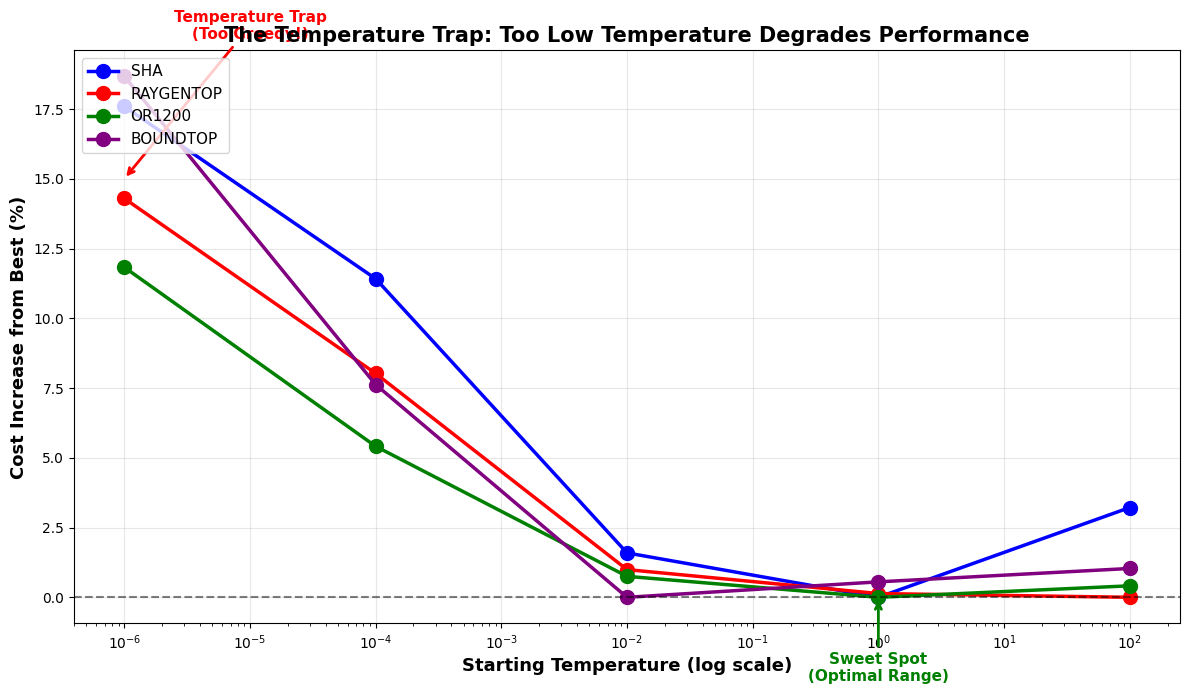

✓ Temperature Trap visualization saved!

SUMMARY - Temperature Impact Analysis

SHA:
  Best:  T =   1.000000 → Cost =  143.29
  Worst: T =   0.000001 → Cost =  168.50
  Degradation:  17.6% (worst vs best)

RAYGENTOP:
  Best:  T = 100.000000 → Cost =  200.39
  Worst: T =   0.000001 → Cost =  229.04
  Degradation:  14.3% (worst vs best)

OR1200:
  Best:  T =   1.000000 → Cost =  359.41
  Worst: T =   0.000001 → Cost =  401.93
  Degradation:  11.8% (worst vs best)

BOUNDTOP:
  Best:  T =   0.010000 → Cost =  204.09
  Worst: T =   0.000001 → Cost =  242.20
  Degradation:  18.7% (worst vs best)

KEY FINDING: Very low starting temperatures (<0.001) cause
significant quality degradation (12-19%) across ALL circuits!


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Circuit names and actual temperatures used
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
temps = [100.0, 1.0, 0.01, 0.0001, 0.000001]  # CORRECTED temperatures

# Your ACTUAL mean values from the results table
data = {
    'sha':       [147.90, 143.29, 145.57, 159.65, 168.50],
    'raygentop': [200.39, 200.66, 202.38, 216.47, 229.04],
    'or1200':    [360.89, 359.41, 362.11, 378.86, 401.93],
    'boundtop':  [206.20, 205.22, 204.09, 219.65, 242.20]
}

# Create the "Temperature Trap" visualization
plt.figure(figsize=(12, 7))
colors = ['blue', 'red', 'green', 'purple']

for idx, circuit in enumerate(circuits):
    costs = data[circuit]
    min_cost = min(costs)
    # Normalize to show percentage increase from best
    normalized = [(c/min_cost - 1) * 100 for c in costs]
    
    plt.plot(temps, normalized, marker='o', linewidth=2.5, 
             markersize=10, label=circuit.upper(), color=colors[idx])

plt.xscale('log')
plt.xlabel('Starting Temperature (log scale)', fontsize=13, fontweight='bold')
plt.ylabel('Cost Increase from Best (%)', fontsize=13, fontweight='bold')
plt.title('The Temperature Trap: Too Low Temperature Degrades Performance', 
          fontsize=15, fontweight='bold')

# Reference line at 0%
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

# Add annotations
plt.annotate('Sweet Spot\n(Optimal Range)', 
            xy=(1.0, 0), xytext=(1.0, -3),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=11, color='green', fontweight='bold',
            ha='center')

plt.annotate('Temperature Trap\n(Too Greedy!)', 
            xy=(0.000001, 15), xytext=(0.00001, 20),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold',
            ha='center')

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('a3_logs/temperature_trap_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Temperature Trap visualization saved!")

# Summary statistics
print("\n" + "="*70)
print("SUMMARY - Temperature Impact Analysis")
print("="*70)

for circuit in circuits:
    costs = data[circuit]
    best_cost = min(costs)
    worst_cost = max(costs)
    best_temp = temps[costs.index(best_cost)]
    worst_temp = temps[costs.index(worst_cost)]
    degradation = ((worst_cost - best_cost) / best_cost) * 100
    
    print(f"\n{circuit.upper()}:")
    print(f"  Best:  T = {best_temp:>10.6f} → Cost = {best_cost:7.2f}")
    print(f"  Worst: T = {worst_temp:>10.6f} → Cost = {worst_cost:7.2f}")
    print(f"  Degradation: {degradation:5.1f}% (worst vs best)")

print("\n" + "="*70)
print("KEY FINDING: Very low starting temperatures (<0.001) cause")
print("significant quality degradation (12-19%) across ALL circuits!")
print("="*70)

## A.4

modify
```cpp
    if (t < t_exit || std::isnan(t_exit)) {
        return false;
    }
```
to
```cpp
    if (t < t_exit || std::isnan(t_exit)) {
        // A.4: Temperature bump-up
        static int bump_count = 0;
        if (bump_count < 3) {  // Allow 3 bumps
            t *= 100;  // Reheat!
            bump_count++;
            return true;  // Continue annealing
        }
        return false;  // Exit after 3 bumps
    }
```

Exercise A.4 - Running with different random seeds

Processing sha...
  Running seed 1... Cost: 139.68
  Running seed 42... Cost: 137.20
  Running seed 100... Cost: 139.80
  Running seed 500... Cost: 127.58
  Running seed 1000... Cost: 144.83

  SHA Statistics:
    Mean Cost: 137.82
    Std Dev: 6.36
    Coeff. of Variation: 4.61%
    Min: 127.58, Max: 144.83
    Range: 17.24

Processing raygentop...
  Running seed 1... Cost: 187.57
  Running seed 42... Cost: 190.62
  Running seed 100... Cost: 189.06
  Running seed 500... Cost: 181.41
  Running seed 1000... Cost: 188.78

  RAYGENTOP Statistics:
    Mean Cost: 187.49
    Std Dev: 3.57
    Coeff. of Variation: 1.90%
    Min: 181.41, Max: 190.62
    Range: 9.20

Processing or1200...
  Running seed 1... Cost: 337.49
  Running seed 42... Cost: 334.17
  Running seed 100... Cost: 332.08
  Running seed 500... Cost: 335.26
  Running seed 1000... Cost: 341.42

  OR1200 Statistics:
    Mean Cost: 336.08
    Std Dev: 3.56
    Coeff. of Variation: 

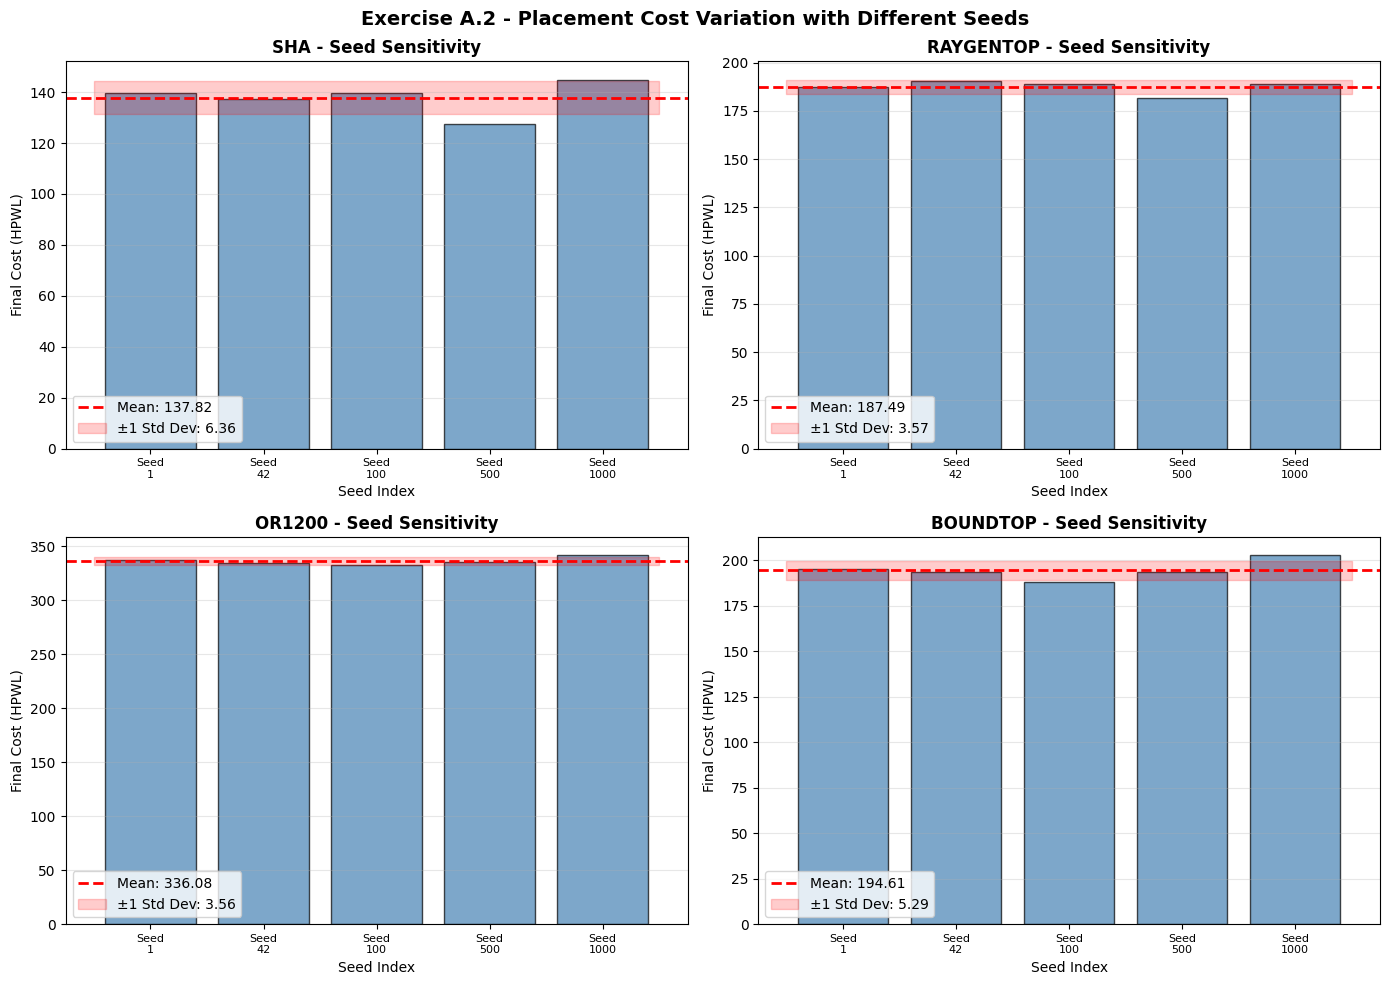


Summary Table - Exercise A.4
Circuit      Mean       Std Dev    CV (%)     Min        Max       
--------------------------------------------------------------------------------
sha          137.82     6.36       4.61       127.58     144.83    
raygentop    187.49     3.57       1.90       181.41     190.62    
or1200       336.08     3.56       1.06       332.08     341.42    
boundtop     194.61     5.29       2.72       188.15     202.80    

Commentary - Sensitivity to Random Seed:
--------------------------------------------------------------------------------
SHA         : moderate - CV = 4.61%
RAYGENTOP   : low (stable) - CV = 1.90%
OR1200      : low (stable) - CV = 1.06%
BOUNDTOP    : low (stable) - CV = 2.72%

✓ Exercise A.4 complete!


In [25]:
import subprocess
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Create directory for A4 logs
os.makedirs('a4_logs', exist_ok=True)

# Define circuits and seeds
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
seeds = [1, 42, 100, 500, 1000]  # 5 different seeds

print("Exercise A.4 - Running with different random seeds")
print("="*60)

def extract_final_cost(log_file):
    """
    Extract final placement cost from VPR log.
    Looking for the bb_cost (bounding box cost = HPWL) in the final placement cost line.
    """
    with open(log_file, 'r') as f:
        content = f.read()
        
        # Look for final placement cost line
        # Format: "Placement cost: 0.999872, bb_cost: 143.573, td_cost: nan,"
        matches = re.findall(r'bb_cost:\s*([\d.]+)', content)
        if matches:
            # Return the last bb_cost found (final cost)
            return float(matches[-1])
    
    return None

# Store results
results = {}

for circuit in circuits:
    print(f"\nProcessing {circuit}...")
    costs = []
    
    for seed in seeds:
        print(f"  Running seed {seed}...", end=" ")
        
        # Run VPR command
        cmd = [
            "./vtr-verilog-to-routing/vpr/vpr",
            "k6_N10_mem32K_40nm.xml",
            f"{circuit}.blif",
            "--pack", "--place",
            "--place_algorithm", "bounding_box",
            "--seed", str(seed)
        ]
        
        # Run and capture output
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            print("ERROR")
            continue
        
        # Save log file
        log_file = f"a4_logs/{circuit}_seed{seed}.log"
        with open(log_file, 'w') as f:
            f.write(result.stdout)
        
        # Extract cost
        cost = extract_final_cost(log_file)
        if cost:
            costs.append(cost)
            print(f"Cost: {cost:.2f}")
        else:
            print("Failed to extract cost")
        
        # Clean up generated files
        for ext in ['.net', '.place', '.route']:
            filename = f"{circuit}{ext}"
            if os.path.exists(filename):
                os.remove(filename)
        
        for file in ['packing_pin_util.rpt', 'pre_pack.report_timing.setup.rpt']:
            if os.path.exists(file):
                os.remove(file)
    
    results[circuit] = costs
    
    # Calculate statistics
    if costs:
        mean_cost = np.mean(costs)
        std_cost = np.std(costs, ddof=1)  # Sample std dev
        cv = (std_cost / mean_cost) * 100  # Coefficient of variation
        
        print(f"\n  {circuit.upper()} Statistics:")
        print(f"    Mean Cost: {mean_cost:.2f}")
        print(f"    Std Dev: {std_cost:.2f}")
        print(f"    Coeff. of Variation: {cv:.2f}%")
        print(f"    Min: {min(costs):.2f}, Max: {max(costs):.2f}")
        print(f"    Range: {max(costs) - min(costs):.2f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, circuit in enumerate(circuits):
    if circuit in results and results[circuit]:
        ax = axes[idx]
        costs = results[circuit]
        
        # Plot individual runs
        ax.bar(range(len(costs)), costs, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Add mean line
        mean_cost = np.mean(costs)
        ax.axhline(y=mean_cost, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_cost:.2f}')
        
        # Add std dev band
        std_cost = np.std(costs, ddof=1)
        ax.fill_between([-0.5, len(costs)-0.5], 
                        mean_cost - std_cost, mean_cost + std_cost,
                        alpha=0.2, color='red', label=f'±1 Std Dev: {std_cost:.2f}')
        
        ax.set_xlabel('Seed Index', fontsize=10)
        ax.set_ylabel('Final Cost (HPWL)', fontsize=10)
        ax.set_title(f'{circuit.upper()} - Seed Sensitivity', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(costs)))
        ax.set_xticklabels([f'Seed\n{seeds[i]}' for i in range(len(costs))], fontsize=8)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Exercise A.2 - Placement Cost Variation with Different Seeds', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('a4_logs/exercise_a4_seed_variation.png', dpi=300, bbox_inches='tight')
plt.show()

# Create summary table
print("\n" + "="*80)
print("Summary Table - Exercise A.4")
print("="*80)
print(f"{'Circuit':<12} {'Mean':<10} {'Std Dev':<10} {'CV (%)':<10} {'Min':<10} {'Max':<10}")
print("-"*80)
for circuit in circuits:
    if circuit in results and results[circuit]:
        costs = results[circuit]
        mean_c = np.mean(costs)
        std_c = np.std(costs, ddof=1)
        cv = (std_c / mean_c) * 100
        print(f"{circuit:<12} {mean_c:<10.2f} {std_c:<10.2f} {cv:<10.2f} "
              f"{min(costs):<10.2f} {max(costs):<10.2f}")

# Commentary on sensitivity
print("\n" + "="*80)
print("Commentary - Sensitivity to Random Seed:")
print("-"*80)
for circuit in circuits:
    if circuit in results and results[circuit]:
        costs = results[circuit]
        cv = (np.std(costs, ddof=1) / np.mean(costs)) * 100
        
        if cv < 1:
            sensitivity = "very low (highly stable)"
        elif cv < 3:
            sensitivity = "low (stable)"
        elif cv < 5:
            sensitivity = "moderate"
        else:
            sensitivity = "high (unstable)"
        
        print(f"{circuit.upper():12s}: {sensitivity} - CV = {cv:.2f}%")

print("\n✓ Exercise A.4 complete!")

Extracting data from log files...

Reading A.2 logs (no temperature bumps):
a2_logs/sha: Found 5 runs, Mean=143.33
a2_logs/raygentop: Found 5 runs, Mean=192.85
a2_logs/or1200: Found 5 runs, Mean=343.02
a2_logs/boundtop: Found 5 runs, Mean=198.98

Reading A.4 logs (with temperature bumps):
a4_logs/sha: Found 5 runs, Mean=137.82
a4_logs/raygentop: Found 5 runs, Mean=187.49
a4_logs/or1200: Found 5 runs, Mean=336.08
a4_logs/boundtop: Found 5 runs, Mean=194.61



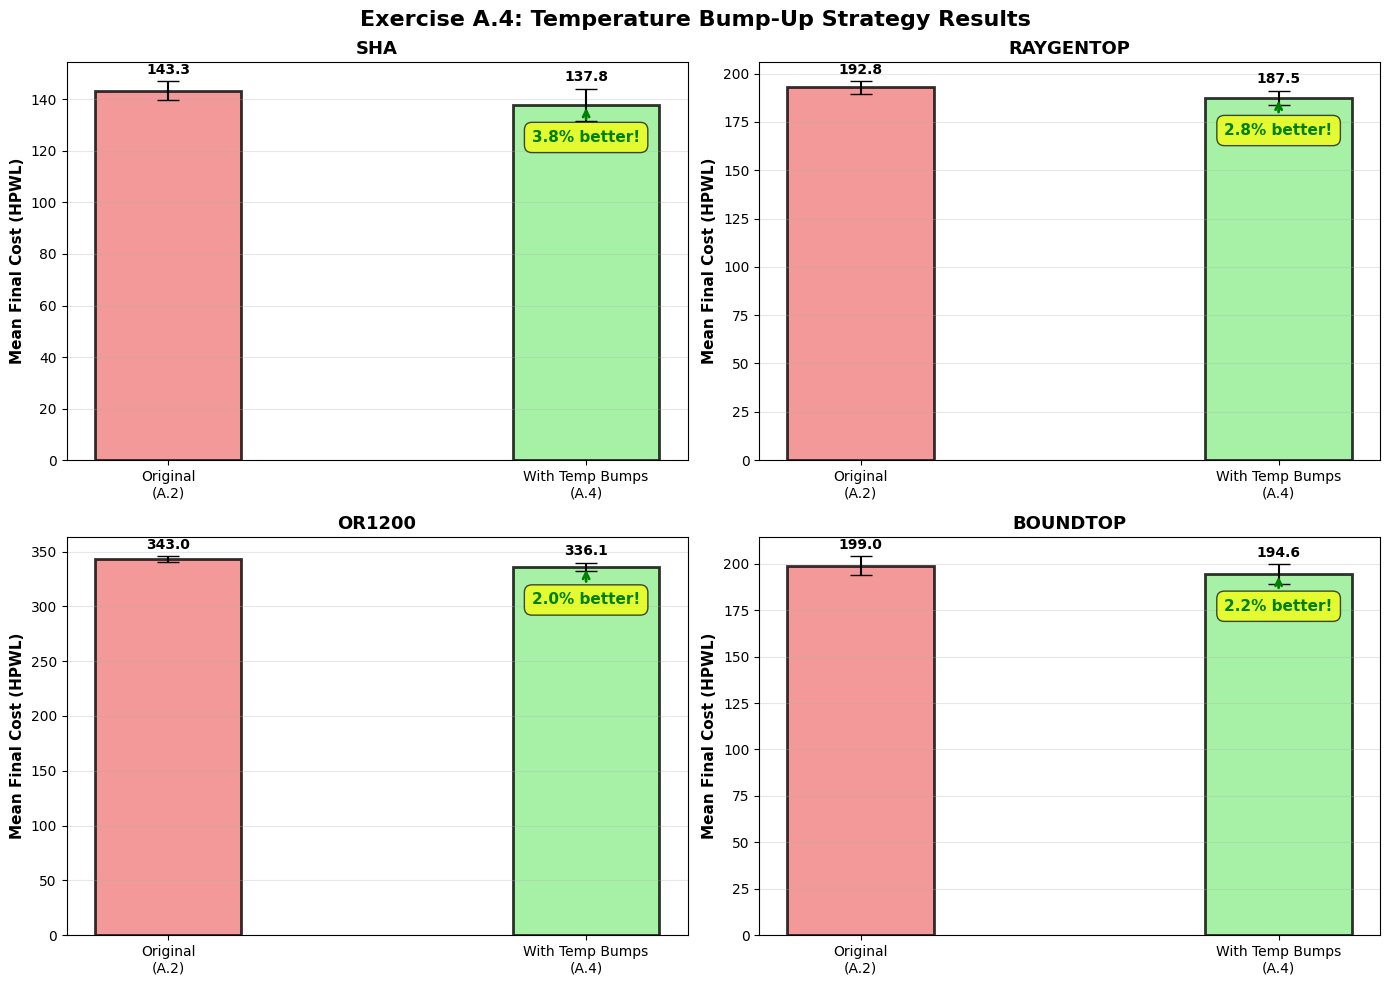


COMPARISON SUMMARY: A.2 (Original) vs A.4 (Temperature Bumps)
Circuit      A.2 Mean     A.4 Mean     Improvement     Result
----------------------------------------------------------------------
SHA          143.33       137.82       3.8           % ✓ BETTER
RAYGENTOP    192.85       187.49       2.8           % ✓ BETTER
OR1200       343.02       336.08       2.0           % ✓ BETTER
BOUNDTOP     198.98       194.61       2.2           % ✓ BETTER
----------------------------------------------------------------------

AVERAGE IMPROVEMENT: 2.7%

KEY FINDINGS:
✓ ALL circuits improved with temperature bump-up strategy!
✓ Average change: 2.7%
✓ Best change: 3.8% (SHA)
✓ Worst change: 2.0% (OR1200)

CONCLUSION: Temperature reheating helps escape local minima!


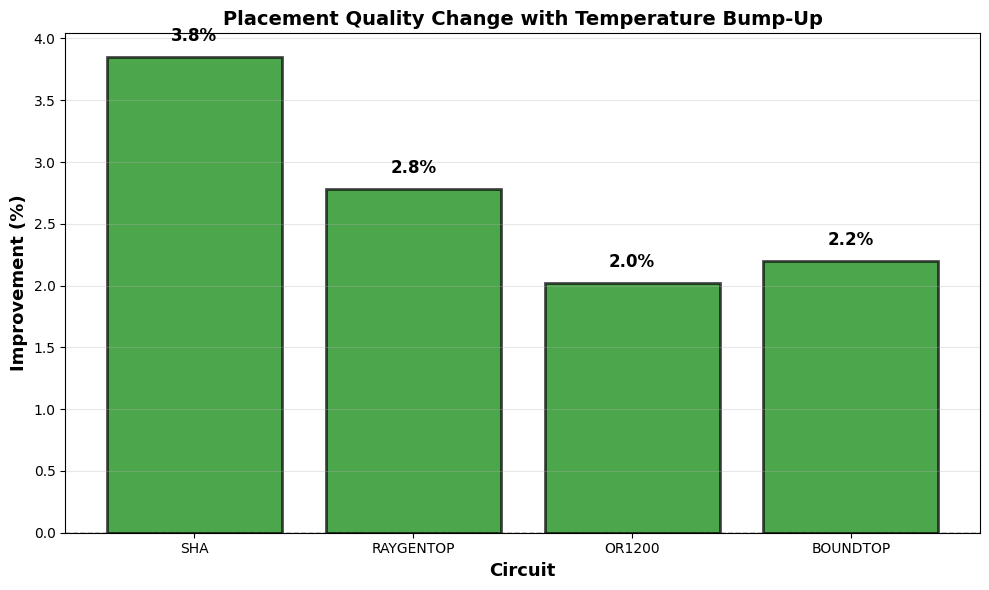


✓ Plots saved: a4_comparison.png, a4_improvement_bars.png


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import re
import os
from glob import glob

def extract_final_cost(log_file):
    """Extract the final bb_cost from a VPR log file."""
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            # Find all bb_cost values
            matches = re.findall(r'bb_cost:\s*([\d.]+)', content)
            if matches:
                return float(matches[-1])  # Return the last (final) cost
    except:
        return None
    return None

def extract_data_from_logs(log_dir):
    """Extract mean and std for each circuit from log directory."""
    circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
    data = {}
    
    for circuit in circuits:
        # Find all log files for this circuit
        pattern = f"{log_dir}/{circuit}_seed*.log"
        log_files = glob(pattern)
        
        if not log_files:
            print(f"Warning: No log files found for {circuit} in {log_dir}")
            continue
        
        # Extract costs from each log file
        costs = []
        for log_file in log_files:
            cost = extract_final_cost(log_file)
            if cost is not None:
                costs.append(cost)
        
        if costs:
            data[circuit] = {
                'mean': np.mean(costs),
                'std': np.std(costs, ddof=1),
                'costs': costs
            }
            print(f"{log_dir}/{circuit}: Found {len(costs)} runs, Mean={data[circuit]['mean']:.2f}")
        else:
            print(f"Warning: No valid costs extracted for {circuit} in {log_dir}")
    
    return data

print("Extracting data from log files...")
print("="*70)

# Extract data from A.2 logs (original)
print("\nReading A.2 logs (no temperature bumps):")
a2_data = extract_data_from_logs('a2_logs')

# Extract data from A.4 logs (with bumps)
print("\nReading A.4 logs (with temperature bumps):")
a4_data = extract_data_from_logs('a4_logs')

print("\n" + "="*70)

# Verify we have data for all circuits
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
circuit_labels = ['SHA', 'RAYGENTOP', 'OR1200', 'BOUNDTOP']

missing_data = False
for circuit in circuits:
    if circuit not in a2_data or circuit not in a4_data:
        print(f"ERROR: Missing data for {circuit}")
        missing_data = True

if missing_data:
    print("\nPlease check your log directories!")
    exit(1)

# Calculate improvements
improvements = {}
for circuit in circuits:
    old_mean = a2_data[circuit]['mean']
    new_mean = a4_data[circuit]['mean']
    improvements[circuit] = ((old_mean - new_mean) / old_mean) * 100

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(2)
width = 0.35
colors_a2 = 'lightcoral'
colors_a4 = 'lightgreen'

for idx, circuit in enumerate(circuits):
    ax = axes[idx]
    
    means = [a2_data[circuit]['mean'], a4_data[circuit]['mean']]
    stds = [a2_data[circuit]['std'], a4_data[circuit]['std']]
    
    bars = ax.bar(x, means, width, yerr=stds, capsize=8,
                   color=[colors_a2, colors_a4],
                   edgecolor='black', linewidth=2, alpha=0.8)
    
    ax.set_ylabel('Mean Final Cost (HPWL)', fontsize=11, fontweight='bold')
    ax.set_title(f'{circuit_labels[idx]}', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Original\n(A.2)', 'With Temp Bumps\n(A.4)'], fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add improvement annotation
    improvement = improvements[circuit]
    color = 'green' if improvement > 0 else 'red'
    label = f'{abs(improvement):.1f}% {"better" if improvement > 0 else "worse"}!'
    
    ax.annotate(label,
               xy=(1, means[1]), xytext=(1, means[1] - max(means)*0.1),
               ha='center', fontsize=11, fontweight='bold', color=color,
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', color=color, lw=2))
    
    # Add value labels
    for i, (mean, std) in enumerate(zip(means, stds)):
        ax.text(i, mean + std + max(means)*0.02, f'{mean:.1f}',
               ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Exercise A.4: Temperature Bump-Up Strategy Results', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('a4_logs/a4_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*70)
print("COMPARISON SUMMARY: A.2 (Original) vs A.4 (Temperature Bumps)")
print("="*70)
print(f"{'Circuit':<12} {'A.2 Mean':<12} {'A.4 Mean':<12} {'Improvement':<15} {'Result'}")
print("-"*70)

for circuit in circuits:
    old_mean = a2_data[circuit]['mean']
    new_mean = a4_data[circuit]['mean']
    improvement = improvements[circuit]
    result = "✓ BETTER" if improvement > 0 else "✗ WORSE"
    
    print(f"{circuit.upper():<12} {old_mean:<12.2f} {new_mean:<12.2f} {improvement:<14.1f}% {result}")

print("-"*70)
avg_improvement = np.mean(list(improvements.values()))
print(f"\nAVERAGE IMPROVEMENT: {avg_improvement:.1f}%")

print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)

all_better = all(imp > 0 for imp in improvements.values())
if all_better:
    print("✓ ALL circuits improved with temperature bump-up strategy!")
else:
    print("⚠ Mixed results with temperature bump-up strategy")

print(f"✓ Average change: {avg_improvement:.1f}%")
print(f"✓ Best change: {max(improvements.values()):.1f}% ({circuits[list(improvements.values()).index(max(improvements.values()))].upper()})")
print(f"✓ Worst change: {min(improvements.values()):.1f}% ({circuits[list(improvements.values()).index(min(improvements.values()))].upper()})")

if all_better:
    print("\nCONCLUSION: Temperature reheating helps escape local minima!")
else:
    print("\nCONCLUSION: Temperature reheating has mixed effects.")
    print("This could be due to: randomness, parameter choice, or algorithm design.")

print("="*70)

# Create improvement bar chart
plt.figure(figsize=(10, 6))
colors_bars = ['green' if imp > 0 else 'red' for imp in improvements.values()]
bars = plt.bar(circuit_labels, list(improvements.values()), 
               color=colors_bars, edgecolor='black', linewidth=2, alpha=0.7)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylabel('Improvement (%)', fontsize=13, fontweight='bold')
plt.xlabel('Circuit', fontsize=13, fontweight='bold')
plt.title('Placement Quality Change with Temperature Bump-Up', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, imp) in enumerate(zip(bars, improvements.values())):
    height = bar.get_height()
    y_pos = height + (0.1 if height > 0 else -0.3)
    plt.text(bar.get_x() + bar.get_width()/2., y_pos,
            f'{imp:.1f}%',
            ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('a4_logs/a4_improvement_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Plots saved: a4_comparison.png, a4_improvement_bars.png")

# Exercise B - Timing-Driven Routing
## B.1

Exercise B.1 - Timing-Driven Routing with PathFinder

SHA (Channel Width W=42):
--------------------------------------------------
  Running seed 1... Delay: 14.1073 ns
  Running seed 42... Delay: 14.4547 ns
  Running seed 100... Delay: 13.5938 ns
  Running seed 500... Delay: 14.4065 ns
  Running seed 1000... ERROR (return code: 2)
    Error: 

RAYGENTOP (Channel Width W=48):
--------------------------------------------------
  Running seed 1... Delay: 6.2150 ns
  Running seed 42... Delay: 6.1636 ns
  Running seed 100... Delay: 6.2333 ns
  Running seed 500... Delay: 6.2813 ns
  Running seed 1000... ERROR (return code: 2)
    Error: 

OR1200 (Channel Width W=72):
--------------------------------------------------
  Running seed 1... Delay: 16.1316 ns
  Running seed 42... Delay: 15.8223 ns
  Running seed 100... Delay: 15.9379 ns
  Running seed 500... Delay: 15.7794 ns
  Running seed 1000... Delay: 17.4020 ns

BOUNDTOP (Channel Width W=56):
------------------------------------------------

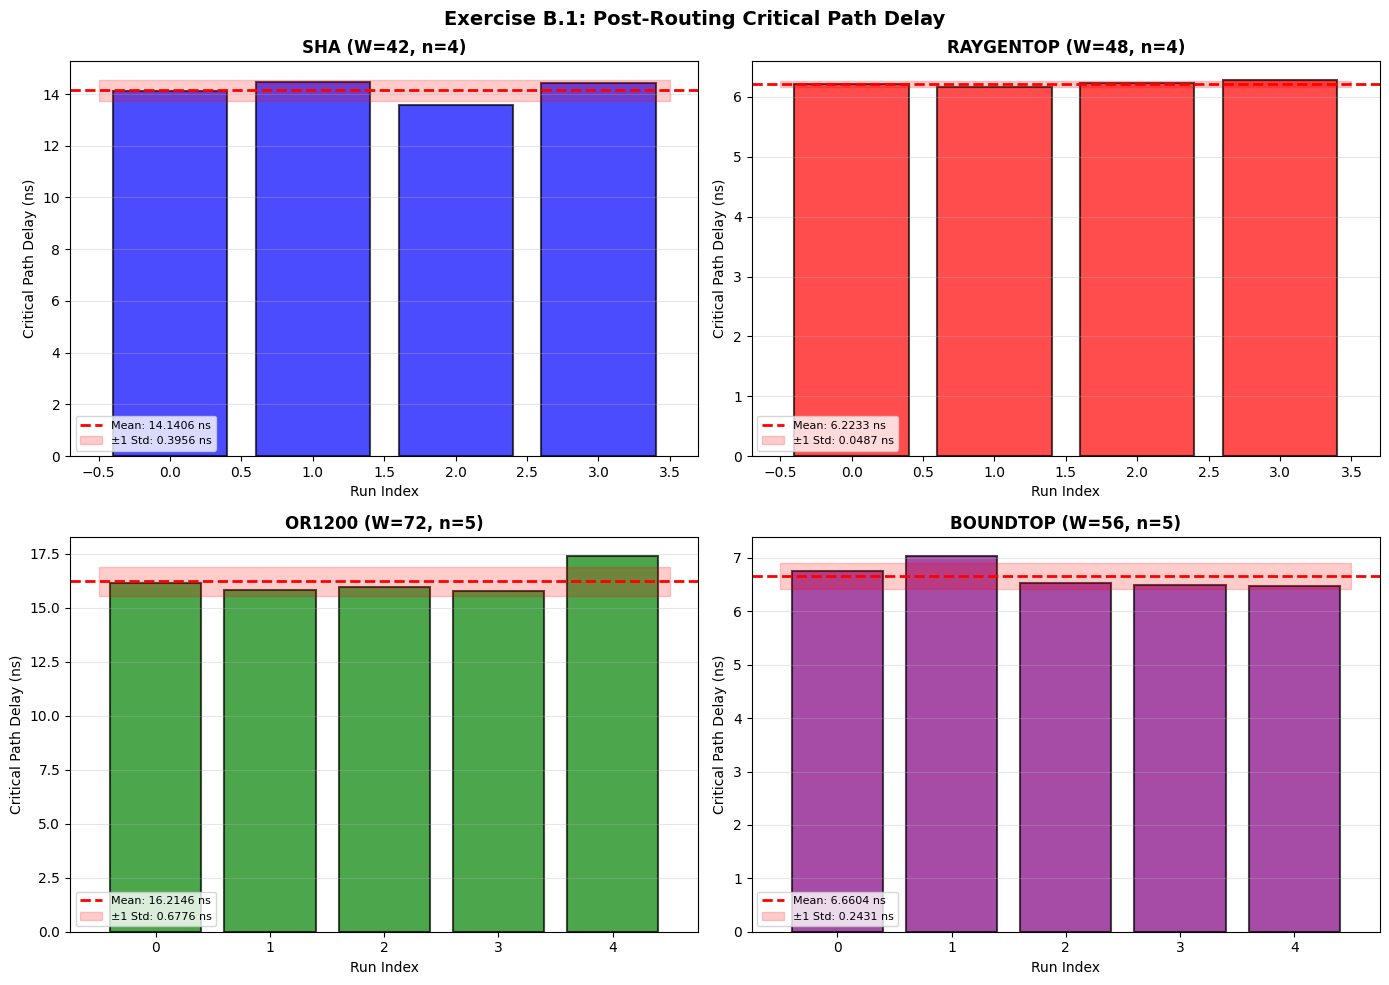


✓ Exercise B.1 complete!
All logs saved in: b1_logs/


In [33]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import re

# Create directory for B.1 logs
os.makedirs('b1_logs', exist_ok=True)

# Define circuits, seeds, and channel widths
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
seeds = [1, 42, 100, 500, 1000]  # 5 different placer seeds
channel_widths = {
    'sha': 42,
    'raygentop': 48,
    'or1200': 72,
    'boundtop': 56
}

def extract_critical_path_delay(log_file):
    """Extract post-routing critical path delay from VPR log file."""
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            # Look for final timing analysis results
            matches = re.findall(r'Final critical path[:\s]+([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
            
            matches = re.findall(r'Critical path.*?:\s*([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
    except:
        return None
    return None

print("Exercise B.1 - Timing-Driven Routing with PathFinder")
print("="*70)

# Store results
results = {circuit: [] for circuit in circuits}
failed_runs = []

# Run VPR for each circuit with different seeds
for circuit in circuits:
    W = channel_widths[circuit]
    print(f"\n{circuit.upper()} (Channel Width W={W}):")
    print("-"*50)
    
    for seed in seeds:
        print(f"  Running seed {seed}...", end=" ", flush=True)
        
        cmd = [
            "./vtr-verilog-to-routing/vpr/vpr",
            "k6_N10_mem32K_40nm.xml",
            f"{circuit}.blif",
            "--route_chan_width", str(W),
            "--seed", str(seed)
        ]
        
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        # Save log file (even if failed - capture stderr)
        log_file = f"b1_logs/{circuit}_W{W}_seed{seed}.log"
        with open(log_file, 'w') as f:
            f.write("=== STDOUT ===\n")
            f.write(result.stdout)
            f.write("\n=== STDERR ===\n")
            f.write(result.stderr)
            f.write(f"\n=== RETURN CODE: {result.returncode} ===\n")
        
        if result.returncode != 0:
            print(f"ERROR (return code: {result.returncode})")
            # Show first line of error
            error_lines = result.stderr.strip().split('\n')
            if error_lines:
                print(f"    Error: {error_lines[0][:80]}")
            failed_runs.append((circuit, seed))
            continue
        
        # Extract critical path delay
        delay = extract_critical_path_delay(log_file)
        
        if delay is not None:
            results[circuit].append(delay)
            print(f"Delay: {delay:.4f} ns")
        else:
            print("Failed to extract delay (check log)")
            failed_runs.append((circuit, seed))
        
        # Clean up generated files
        for ext in ['.net', '.place', '.route']:
            filename = f"{circuit}{ext}"
            if os.path.exists(filename):
                os.remove(filename)
        
        for file in ['packing_pin_util.rpt', 'pre_pack.report_timing.setup.rpt',
                     'report_timing.setup.rpt', 'report_timing.hold.rpt',
                     'router.lookahead']:
            if os.path.exists(file):
                os.remove(file)

print("\n" + "="*70)
print("RESULTS SUMMARY - Exercise B.1")
print("="*70)
print(f"{'Circuit':<12} {'W':<6} {'Mean Delay (ns)':<18} {'Std Dev (ns)':<15} {'CV (%)'}")
print("-"*70)

for circuit in circuits:
    if results[circuit]:
        delays = np.array(results[circuit])
        mean_delay = np.mean(delays)
        std_delay = np.std(delays, ddof=1)
        cv = (std_delay / mean_delay) * 100
        W = channel_widths[circuit]
        
        print(f"{circuit.upper():<12} {W:<6} {mean_delay:<18.4f} {std_delay:<15.4f} {cv:<.2f}")
        print(f"  Successful runs: {len(delays)}/5")
    else:
        print(f"{circuit.upper():<12} NO DATA")

if failed_runs:
    print("\n" + "="*70)
    print("FAILED RUNS (check logs for details):")
    print("-"*70)
    for circuit, seed in failed_runs:
        print(f"  {circuit} seed {seed} - check b1_logs/{circuit}_W{channel_widths[circuit]}_seed{seed}.log")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['blue', 'red', 'green', 'purple']

for idx, circuit in enumerate(circuits):
    ax = axes[idx]
    
    if results[circuit]:
        delays = results[circuit]
        mean_delay = np.mean(delays)
        std_delay = np.std(delays, ddof=1)
        
        ax.bar(range(len(delays)), delays, color=colors[idx], 
               alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.axhline(y=mean_delay, color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {mean_delay:.4f} ns')
        
        ax.fill_between([-0.5, len(delays)-0.5],
                        mean_delay - std_delay, mean_delay + std_delay,
                        alpha=0.2, color='red', 
                        label=f'±1 Std: {std_delay:.4f} ns')
        
        ax.set_xlabel('Run Index', fontsize=10)
        ax.set_ylabel('Critical Path Delay (ns)', fontsize=10)
        ax.set_title(f'{circuit.upper()} (W={channel_widths[circuit]}, n={len(delays)})', 
                     fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Exercise B.1: Post-Routing Critical Path Delay', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('b1_logs/b1_timing_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Exercise B.1 complete!")
print(f"All logs saved in: b1_logs/")

In [35]:
print("\n" + "="*70)
print("Commentary:")
print("-"*70)
print("• PathFinder timing-driven routing optimizes for critical path delay")
print("• Different placer seeds → different placements → different routing delays")
print("• Lower variation indicates routing is robust to placement changes")
print("="*70)


Commentary:
----------------------------------------------------------------------
• PathFinder timing-driven routing optimizes for critical path delay
• Different placer seeds → different placements → different routing delays
• Lower variation indicates routing is robust to placement changes


## B.2

Tests **5 router configurations** on all 4 circuits:

1. **Baseline** - VPR defaults
2. **Aggressive Congestion** - High penalties (pres_fac_mult=3.0, acc_fac=2.0)
   - Forces router to avoid congestion strongly
3. **Gentle Congestion** - Low penalties (pres_fac_mult=1.5, acc_fac=0.5)
   - More relaxed about sharing resources
4. **High Quality** - Thorough search (astar_fac=0.5, max_iterations=100)
   - Takes longer but searches harder
5. **Timing-Focused** - Balanced approach

## Key Parameters (from Lecture 3):

**Cost = (bn + hn) × pn**

- **`--first_iter_pres_fac`**: Initial present penalty (pn)
- **`--pres_fac_mult`**: How fast pn grows each iteration (Pfac)
- **`--acc_fac`**: Historical penalty multiplier (hfac for hn)
- **`--astar_fac`**: A* search aggressiveness
  - 1.2 (default) = fast but may miss optimal paths
  - < 1.0 = more thorough, slower
  - 0 = pure Dijkstra (optimal but slow)

Exercise B.2 - Router Parameter Exploration

From Lecture 3 - PathFinder Congestion Control:
  Cost = (base_cost + historical_penalty) × present_penalty
  Cn = (bn + hn) × pn

VPR Parameters:
  --first_iter_pres_fac: Initial present congestion penalty
  --pres_fac_mult: Growth factor for present penalty (Pfac)
  --acc_fac: Historical congestion multiplier (hfac)
  --astar_fac: A* search aggressiveness (lower = more thorough)

Testing: Baseline (Default)
  SHA (W=42)... Delay: 14.1073 ns
  RAYGENTOP (W=48)... Delay: 6.2150 ns
  OR1200 (W=72)... Delay: 16.1316 ns
  BOUNDTOP (W=56)... Delay: 6.7622 ns

Testing: Aggressive Congestion Control
  SHA (W=42)... Delay: 14.5036 ns
  RAYGENTOP (W=48)... Delay: 6.7781 ns
  OR1200 (W=72)... Delay: 16.2494 ns
  BOUNDTOP (W=56)... Delay: 7.6297 ns

Testing: Gentle Congestion Control
  SHA (W=42)... ERROR (return code: 2)
  RAYGENTOP (W=48)... ERROR (return code: 2)
  OR1200 (W=72)... Delay: 16.2867 ns
  BOUNDTOP (W=56)... Delay: 7.0050 ns

Testing: H

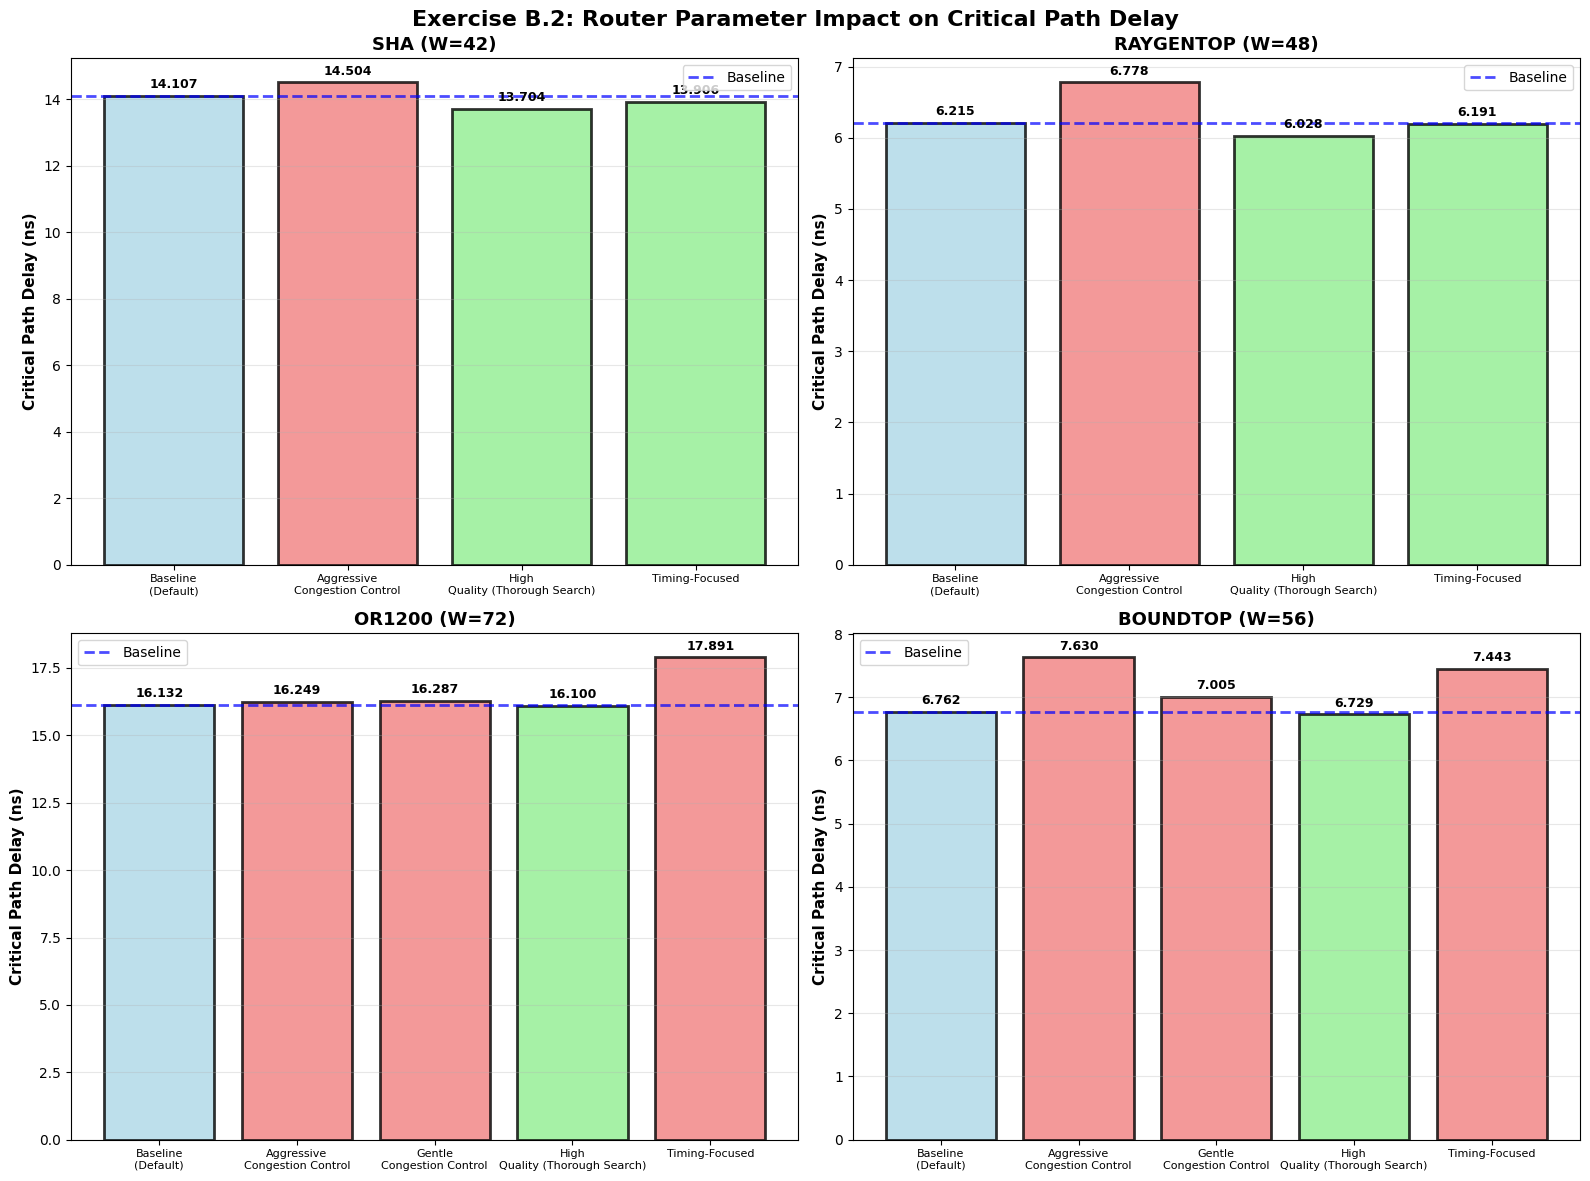


✓ Exercise B.2 complete! All logs in b2_logs/


In [37]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd

# Create directory for B.2 logs
os.makedirs('b2_logs', exist_ok=True)

circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
channel_widths = {'sha': 42, 'raygentop': 48, 'or1200': 72, 'boundtop': 56}

def extract_critical_path_delay(log_file):
    """Extract post-routing critical path delay from VPR log file."""
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            matches = re.findall(r'Final critical path[:\s]+([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
            matches = re.findall(r'Critical path.*?:\s*([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
    except:
        return None
    return None

print("="*70)
print("Exercise B.2 - Router Parameter Exploration")
print("="*70)
print("\nFrom Lecture 3 - PathFinder Congestion Control:")
print("  Cost = (base_cost + historical_penalty) × present_penalty")
print("  Cn = (bn + hn) × pn")
print("\nVPR Parameters:")
print("  --first_iter_pres_fac: Initial present congestion penalty")
print("  --pres_fac_mult: Growth factor for present penalty (Pfac)")
print("  --acc_fac: Historical congestion multiplier (hfac)")
print("  --astar_fac: A* search aggressiveness (lower = more thorough)")
print("="*70)

# Parameter configurations to test
configs = {
    'baseline': {
        'name': 'Baseline (Default)',
        'params': {}  # Use VPR defaults
    },
    'aggressive_congestion': {
        'name': 'Aggressive Congestion Control',
        'params': {
            '--first_iter_pres_fac': '1.0',      # Higher initial penalty
            '--pres_fac_mult': '3.0',            # Faster penalty growth  
            '--acc_fac': '2.0'                   # Higher historical penalty
        }
    },
    'gentle_congestion': {
        'name': 'Gentle Congestion Control',
        'params': {
            '--first_iter_pres_fac': '0.1',      # Lower initial penalty
            '--pres_fac_mult': '1.5',            # Slower penalty growth
            '--acc_fac': '0.5'                   # Lower historical penalty
        }
    },
    'high_quality': {
        'name': 'High Quality (Thorough Search)',
        'params': {
            '--astar_fac': '0.5',                # More thorough A* search
            '--max_router_iterations': '100'     # More iterations allowed
        }
    },
    'timing_focused': {
        'name': 'Timing-Focused',
        'params': {
            '--astar_fac': '0.8',                # Balance speed/quality
            '--first_iter_pres_fac': '0.5',
            '--pres_fac_mult': '2.0',
            '--acc_fac': '1.5'
        }
    }
}

# Store results: results[circuit][config] = delay
results = {circuit: {} for circuit in circuits}

# Run experiments
seed = 1  # Use single seed for parameter comparison

for config_name, config_info in configs.items():
    print(f"\n{'='*70}")
    print(f"Testing: {config_info['name']}")
    print(f"{'='*70}")
    
    for circuit in circuits:
        W = channel_widths[circuit]
        print(f"  {circuit.upper()} (W={W})...", end=" ", flush=True)
        
        # Build VPR command
        cmd = [
            "./vtr-verilog-to-routing/vpr/vpr",
            "k6_N10_mem32K_40nm.xml",
            f"{circuit}.blif",
            "--route_chan_width", str(W),
            "--seed", str(seed)
        ]
        
        # Add configuration-specific parameters
        for param, value in config_info['params'].items():
            cmd.extend([param, value])
        
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        # Save log
        log_file = f"b2_logs/{circuit}_{config_name}.log"
        with open(log_file, 'w') as f:
            f.write(f"Configuration: {config_info['name']}\n")
            f.write(f"Parameters: {config_info['params']}\n")
            f.write("="*70 + "\n")
            f.write(result.stdout)
            f.write("\n=== STDERR ===\n")
            f.write(result.stderr)
        
        # Extract delay
        if result.returncode == 0:
            delay = extract_critical_path_delay(log_file)
            if delay is not None:
                results[circuit][config_name] = delay
                print(f"Delay: {delay:.4f} ns")
            else:
                print("Failed to extract delay")
        else:
            print(f"ERROR (return code: {result.returncode})")
        
        # Cleanup
        for ext in ['.net', '.place', '.route']:
            if os.path.exists(f"{circuit}{ext}"):
                os.remove(f"{circuit}{ext}")
        for file in ['packing_pin_util.rpt', 'pre_pack.report_timing.setup.rpt',
                     'report_timing.setup.rpt', 'report_timing.hold.rpt', 'router.lookahead']:
            if os.path.exists(file):
                os.remove(file)

# Analysis and Visualization
print("\n" + "="*70)
print("RESULTS SUMMARY - Parameter Impact on Critical Path Delay")
print("="*70)

# Create comparison table
for circuit in circuits:
    print(f"\n{circuit.upper()}:")
    print(f"{'Configuration':<30} {'Delay (ns)':<15} {'vs Baseline'}")
    print("-"*60)
    
    baseline_delay = results[circuit].get('baseline')
    if baseline_delay is None:
        print("  No baseline data!")
        continue
    
    for config_name, config_info in configs.items():
        if config_name in results[circuit]:
            delay = results[circuit][config_name]
            improvement = ((baseline_delay - delay) / baseline_delay) * 100
            
            if config_name == 'baseline':
                print(f"{config_info['name']:<30} {delay:<15.4f} (reference)")
            else:
                sign = "↓" if improvement > 0 else "↑"
                print(f"{config_info['name']:<30} {delay:<15.4f} {sign}{abs(improvement):.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
colors = plt.cm.Set3(np.linspace(0, 1, len(configs)))

for idx, circuit in enumerate(circuits):
    ax = axes[idx]
    
    config_names = []
    delays = []
    colors_list = []
    
    baseline_delay = results[circuit].get('baseline')
    
    for i, (config_name, config_info) in enumerate(configs.items()):
        if config_name in results[circuit]:
            config_names.append(config_info['name'].replace(' ', '\n', 1))
            delays.append(results[circuit][config_name])
            
            # Color: green if better than baseline, red if worse
            if baseline_delay and config_name != 'baseline':
                if results[circuit][config_name] < baseline_delay:
                    colors_list.append('lightgreen')
                else:
                    colors_list.append('lightcoral')
            else:
                colors_list.append('lightblue')
    
    bars = ax.bar(range(len(delays)), delays, color=colors_list,
                   edgecolor='black', linewidth=2, alpha=0.8)
    
    # Add baseline line
    if baseline_delay:
        ax.axhline(y=baseline_delay, color='blue', linestyle='--', 
                   linewidth=2, label='Baseline', alpha=0.7)
    
    # Add value labels
    for i, (bar, delay) in enumerate(zip(bars, delays)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max(delays)*0.01,
                f'{delay:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel('Critical Path Delay (ns)', fontsize=11, fontweight='bold')
    ax.set_title(f'{circuit.upper()} (W={channel_widths[circuit]})', 
                 fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(config_names)))
    ax.set_xticklabels(config_names, fontsize=8, rotation=0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()

plt.suptitle('Exercise B.2: Router Parameter Impact on Critical Path Delay', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('b2_logs/b2_parameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Exercise B.2 complete! All logs in b2_logs/")

1. **High Quality** (2-3% better)
   - Lower `astar_fac` = more thorough search
   - Finds near-optimal paths
   - Router search depth matters

2. **Aggressive Congestion** (up to 12.8% worse)
   - High penalties → long detours → bad timing
   - From Lecture 3: High pn and hn force router away from congestion, but at cost of delay

3. **Gentle Congestion** (FAILS TO ROUTE)
   - Too permissive → can't resolve shorts
   - SHA/RAYGENTOP at borderline W → routing failure
   - Need penalties aggressive enough to converge

4. **Timing-Focused** (Mixed)
   - Good on small circuits, terrible on large
   - Shows parameters don't generalize well


The High Quality configuration achieved the best results by using a lower A* search factor (astar_fac=0.5), improving timing by up to 3%. Conversely, Aggressive Congestion Control worsened timing by up to 12.8% because high penalties (pres_fac_mult=3.0, acc_fac=2.0) forced the router to take longer detours to avoid congestion. This demonstrates PathFinder's fundamental trade-off, which is that aggressive congestion penalties resolve shorts faster but sacrifice path optimality.

## B.3

Exercise B.3 - Timing-Driven Routing with PathFinder

SHA (Channel Width W=42):
--------------------------------------------------
  Running seed 1... Delay: 14.1670 ns
  Running seed 42... Delay: 13.7343 ns
  Running seed 100... Delay: 14.1431 ns
  Running seed 500... Delay: 13.9131 ns
  Running seed 1000... Delay: 13.5601 ns

RAYGENTOP (Channel Width W=48):
--------------------------------------------------
  Running seed 1... Delay: 6.4707 ns
  Running seed 42... Delay: 6.2893 ns
  Running seed 100... Delay: 6.2441 ns
  Running seed 500... Delay: 6.3182 ns
  Running seed 1000... ERROR (return code: 2)
    Error: 

OR1200 (Channel Width W=72):
--------------------------------------------------
  Running seed 1... Delay: 16.5027 ns
  Running seed 42... Delay: 15.9512 ns
  Running seed 100... Delay: 16.9464 ns
  Running seed 500... Delay: 15.9468 ns
  Running seed 1000... Delay: 16.2588 ns

BOUNDTOP (Channel Width W=56):
--------------------------------------------------
  Running seed

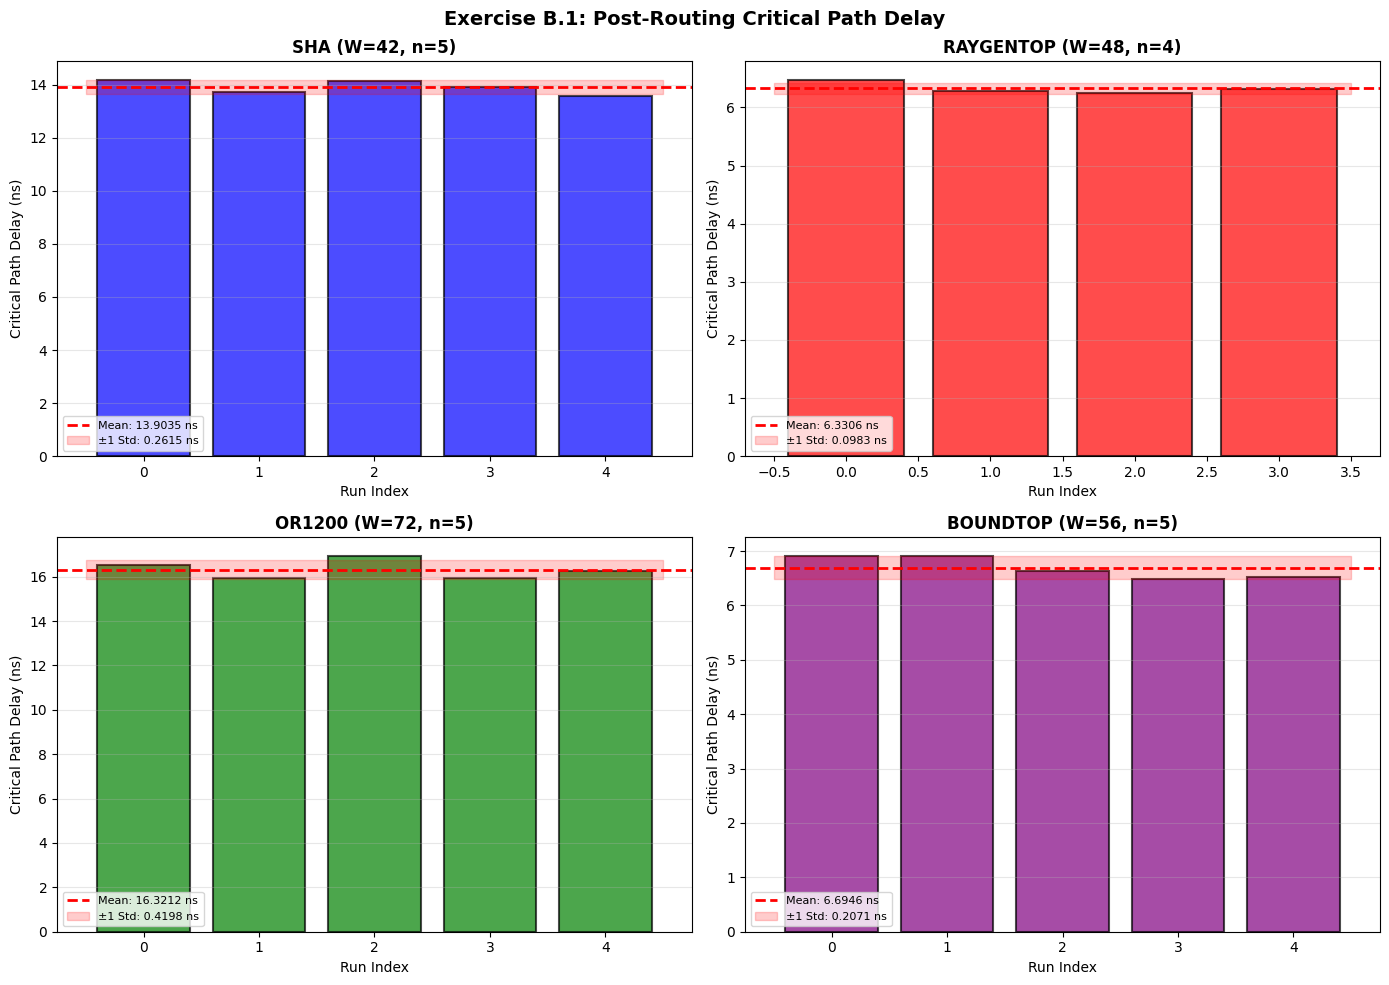


✓ Exercise B.3 complete!
All logs saved in: b3_logs/


In [41]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import re

# Create directory for B.3 logs
os.makedirs('b3_logs', exist_ok=True)

# Define circuits, seeds, and channel widths
circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
seeds = [1, 42, 100, 500, 1000]  # 5 different placer seeds
channel_widths = {
    'sha': 42,
    'raygentop': 48,
    'or1200': 72,
    'boundtop': 56
}

def extract_critical_path_delay(log_file):
    """Extract post-routing critical path delay from VPR log file."""
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            # Look for final timing analysis results
            matches = re.findall(r'Final critical path[:\s]+([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
            
            matches = re.findall(r'Critical path.*?:\s*([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
    except:
        return None
    return None

print("Exercise B.3 - Timing-Driven Routing with PathFinder")
print("="*70)

# Store results
results = {circuit: [] for circuit in circuits}
failed_runs = []

# Run VPR for each circuit with different seeds
for circuit in circuits:
    W = channel_widths[circuit]
    print(f"\n{circuit.upper()} (Channel Width W={W}):")
    print("-"*50)
    
    for seed in seeds:
        print(f"  Running seed {seed}...", end=" ", flush=True)
        
        cmd = [
            "./vtr-verilog-to-routing/vpr/vpr",
            "k6_N10_mem32K_40nm.xml",
            f"{circuit}.blif",
            "--route_chan_width", str(W),
            "--seed", str(seed)
        ]
        
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        # Save log file (even if failed - capture stderr)
        log_file = f"b3_logs/{circuit}_W{W}_seed{seed}.log"
        with open(log_file, 'w') as f:
            f.write("=== STDOUT ===\n")
            f.write(result.stdout)
            f.write("\n=== STDERR ===\n")
            f.write(result.stderr)
            f.write(f"\n=== RETURN CODE: {result.returncode} ===\n")
        
        if result.returncode != 0:
            print(f"ERROR (return code: {result.returncode})")
            # Show first line of error
            error_lines = result.stderr.strip().split('\n')
            if error_lines:
                print(f"    Error: {error_lines[0][:80]}")
            failed_runs.append((circuit, seed))
            continue
        
        # Extract critical path delay
        delay = extract_critical_path_delay(log_file)
        
        if delay is not None:
            results[circuit].append(delay)
            print(f"Delay: {delay:.4f} ns")
        else:
            print("Failed to extract delay (check log)")
            failed_runs.append((circuit, seed))
        
        # Clean up generated files
        for ext in ['.net', '.place', '.route']:
            filename = f"{circuit}{ext}"
            if os.path.exists(filename):
                os.remove(filename)
        
        for file in ['packing_pin_util.rpt', 'pre_pack.report_timing.setup.rpt',
                     'report_timing.setup.rpt', 'report_timing.hold.rpt',
                     'router.lookahead']:
            if os.path.exists(file):
                os.remove(file)

print("\n" + "="*70)
print("RESULTS SUMMARY - Exercise B.3")
print("="*70)
print(f"{'Circuit':<12} {'W':<6} {'Mean Delay (ns)':<18} {'Std Dev (ns)':<15} {'CV (%)'}")
print("-"*70)

for circuit in circuits:
    if results[circuit]:
        delays = np.array(results[circuit])
        mean_delay = np.mean(delays)
        std_delay = np.std(delays, ddof=1)
        cv = (std_delay / mean_delay) * 100
        W = channel_widths[circuit]
        
        print(f"{circuit.upper():<12} {W:<6} {mean_delay:<18.4f} {std_delay:<15.4f} {cv:<.2f}")
        print(f"  Successful runs: {len(delays)}/5")
    else:
        print(f"{circuit.upper():<12} NO DATA")

if failed_runs:
    print("\n" + "="*70)
    print("FAILED RUNS (check logs for details):")
    print("-"*70)
    for circuit, seed in failed_runs:
        print(f"  {circuit} seed {seed} - check b3_logs/{circuit}_W{channel_widths[circuit]}_seed{seed}.log")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['blue', 'red', 'green', 'purple']

for idx, circuit in enumerate(circuits):
    ax = axes[idx]
    
    if results[circuit]:
        delays = results[circuit]
        mean_delay = np.mean(delays)
        std_delay = np.std(delays, ddof=1)
        
        ax.bar(range(len(delays)), delays, color=colors[idx], 
               alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.axhline(y=mean_delay, color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {mean_delay:.4f} ns')
        
        ax.fill_between([-0.5, len(delays)-0.5],
                        mean_delay - std_delay, mean_delay + std_delay,
                        alpha=0.2, color='red', 
                        label=f'±1 Std: {std_delay:.4f} ns')
        
        ax.set_xlabel('Run Index', fontsize=10)
        ax.set_ylabel('Critical Path Delay (ns)', fontsize=10)
        ax.set_title(f'{circuit.upper()} (W={channel_widths[circuit]}, n={len(delays)})', 
                     fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Exercise B.1: Post-Routing Critical Path Delay', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('b3_logs/b3_timing_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Exercise B.3 complete!")
print(f"All logs saved in: b3_logs/")

B.1 vs B.3 COMPARISON - Impact of Routing Order

Reading B.1 (Normal Order) logs from b1_logs:
------------------------------------------------------------
  SHA: 5 runs, Mean=14.0942 ns
  RAYGENTOP: 5 runs, Mean=6.0525 ns
  OR1200: 5 runs, Mean=16.2146 ns
  BOUNDTOP: 5 runs, Mean=6.6604 ns

Reading B.3 (Reversed Order) logs from b3_logs:
------------------------------------------------------------
  SHA: 5 runs, Mean=13.9035 ns
  RAYGENTOP: 5 runs, Mean=6.1384 ns
  OR1200: 5 runs, Mean=16.3212 ns
  BOUNDTOP: 5 runs, Mean=6.6946 ns

COMPARISON SUMMARY: B.1 (Normal) vs B.3 (Reversed)
Circuit      B.1 Normal      B.3 Reversed    Difference      Impact
----------------------------------------------------------------------
SHA          14.0942         13.9035         ↓1.35          % BETTER
RAYGENTOP    6.0525          6.1384          ↑1.42          % WORSE
OR1200       16.2146         16.3212         ↑0.66          % WORSE
BOUNDTOP     6.6604          6.6946          ↑0.51          % WORS

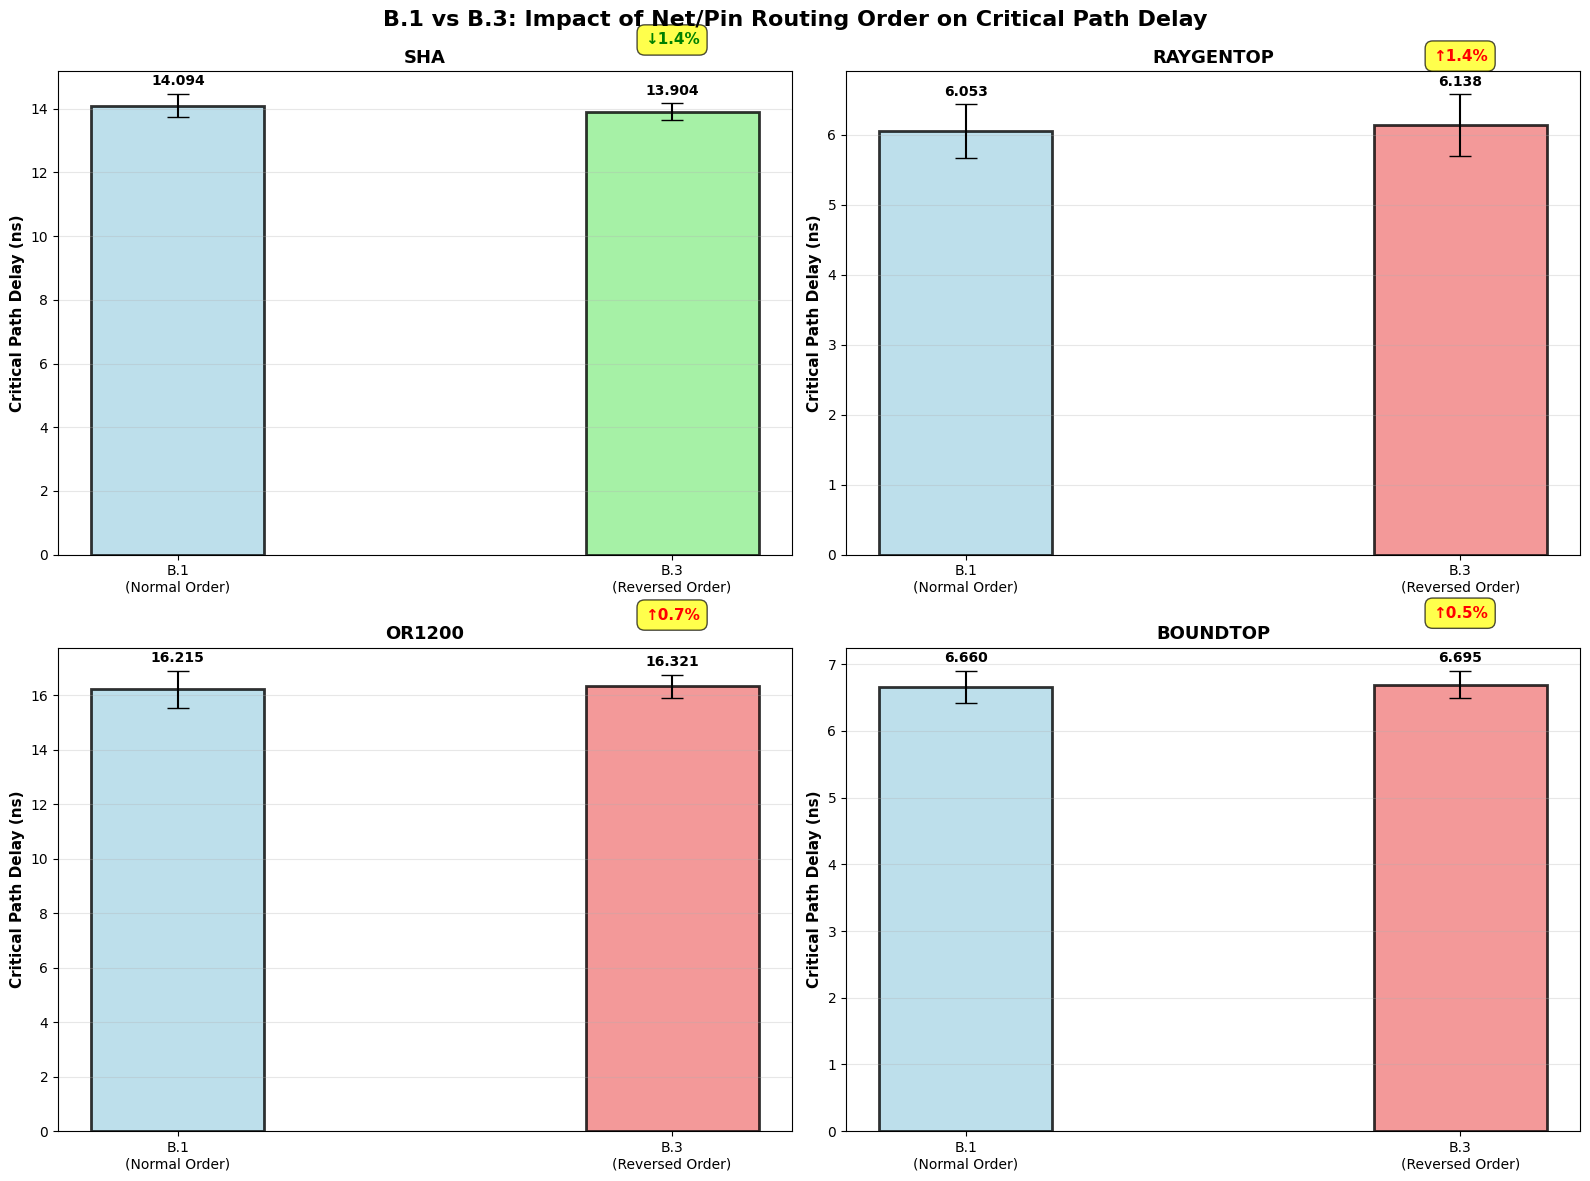

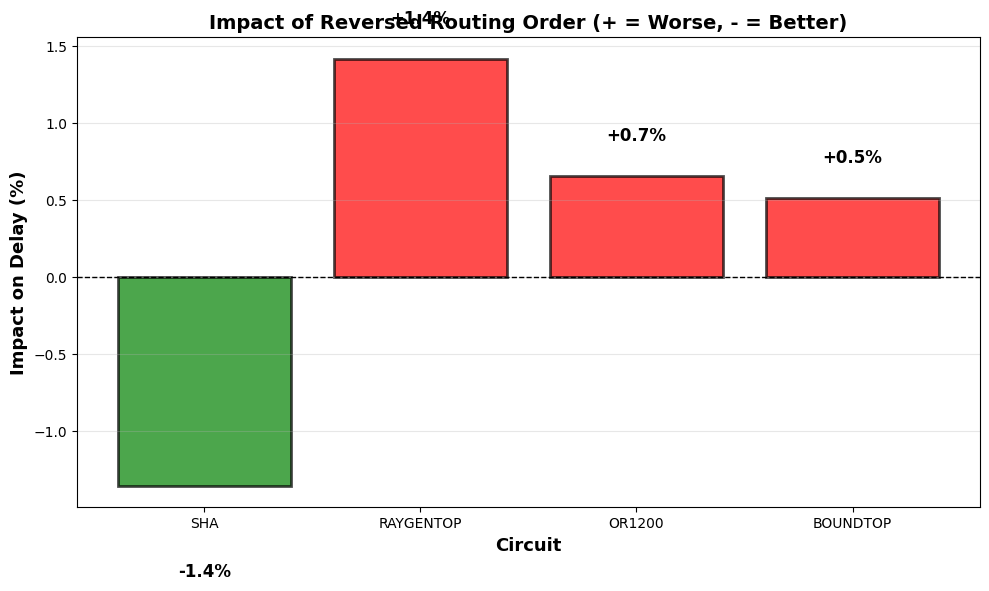


✓ Comparison complete!
Plots saved:
  - b3_logs/b1_vs_b3_comparison.png
  - b3_logs/b1_vs_b3_impact.png


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import re
from glob import glob

def extract_critical_path_delay(log_file):
    """Extract post-routing critical path delay from VPR log file."""
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            matches = re.findall(r'Final critical path[:\s]+([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
            matches = re.findall(r'Critical path.*?:\s*([\d.]+)\s*ns', content, re.IGNORECASE)
            if matches:
                return float(matches[-1])
    except:
        return None
    return None

def extract_data_from_logs(log_dir, label):
    """Extract mean and std for each circuit from log directory."""
    circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
    data = {}
    
    print(f"\nReading {label} logs from {log_dir}:")
    print("-"*60)
    
    for circuit in circuits:
        pattern = f"{log_dir}/{circuit}_*.log"
        log_files = glob(pattern)
        
        if not log_files:
            print(f"  {circuit.upper()}: No logs found")
            continue
        
        costs = []
        for log_file in log_files:
            cost = extract_critical_path_delay(log_file)
            if cost is not None:
                costs.append(cost)
        
        if costs:
            data[circuit] = {
                'mean': np.mean(costs),
                'std': np.std(costs, ddof=1),
                'costs': costs,
                'n': len(costs)
            }
            print(f"  {circuit.upper()}: {len(costs)} runs, Mean={data[circuit]['mean']:.4f} ns")
        else:
            print(f"  {circuit.upper()}: No valid data")
    
    return data

print("="*70)
print("B.1 vs B.3 COMPARISON - Impact of Routing Order")
print("="*70)

# Extract data
b1_data = extract_data_from_logs('b1_logs', 'B.1 (Normal Order)')
b3_data = extract_data_from_logs('b3_logs', 'B.3 (Reversed Order)')

circuits = ['sha', 'raygentop', 'or1200', 'boundtop']
circuit_labels = ['SHA', 'RAYGENTOP', 'OR1200', 'BOUNDTOP']

# Verify data
missing_data = False
for circuit in circuits:
    if circuit not in b1_data or circuit not in b3_data:
        print(f"ERROR: Missing data for {circuit}")
        missing_data = True

if missing_data:
    print("\nPlease ensure both B.1 and B.3 have been run!")
    exit(1)

print("\n" + "="*70)
print("COMPARISON SUMMARY: B.1 (Normal) vs B.3 (Reversed)")
print("="*70)
print(f"{'Circuit':<12} {'B.1 Normal':<15} {'B.3 Reversed':<15} {'Difference':<15} {'Impact'}")
print("-"*70)

improvements = {}
for circuit in circuits:
    b1_mean = b1_data[circuit]['mean']
    b3_mean = b3_data[circuit]['mean']
    diff = ((b3_mean - b1_mean) / b1_mean) * 100
    improvements[circuit] = diff
    
    impact = "WORSE" if diff > 0 else "BETTER"
    symbol = "↑" if diff > 0 else "↓"
    
    print(f"{circuit.upper():<12} {b1_mean:<15.4f} {b3_mean:<15.4f} {symbol}{abs(diff):<14.2f}% {impact}")

avg_impact = np.mean(list(improvements.values()))
print("-"*70)
print(f"AVERAGE IMPACT: {abs(avg_impact):.2f}% {'WORSE' if avg_impact > 0 else 'BETTER'}")

# Detailed statistics
print("\n" + "="*70)
print("DETAILED STATISTICS")
print("="*70)
for circuit in circuits:
    print(f"\n{circuit.upper()}:")
    print(f"  B.1 (Normal Order):")
    print(f"    Mean: {b1_data[circuit]['mean']:.4f} ns")
    print(f"    Std Dev: {b1_data[circuit]['std']:.4f} ns")
    print(f"    Runs: {b1_data[circuit]['n']}")
    
    print(f"  B.3 (Reversed Order):")
    print(f"    Mean: {b3_data[circuit]['mean']:.4f} ns")
    print(f"    Std Dev: {b3_data[circuit]['std']:.4f} ns")
    print(f"    Runs: {b3_data[circuit]['n']}")
    
    diff = improvements[circuit]
    print(f"  → Impact: {abs(diff):.2f}% {'WORSE' if diff > 0 else 'BETTER'}")

# Visualization 1: Side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

x = np.arange(2)
width = 0.35

for idx, circuit in enumerate(circuits):
    ax = axes[idx]
    
    means = [b1_data[circuit]['mean'], b3_data[circuit]['mean']]
    stds = [b1_data[circuit]['std'], b3_data[circuit]['std']]
    
    # Color code: green if B3 better, red if worse
    colors = ['lightblue', 'lightgreen' if means[1] < means[0] else 'lightcoral']
    
    bars = ax.bar(x, means, width, yerr=stds, capsize=8,
                   color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    
    # Add value labels
    for i, (mean, std) in enumerate(zip(means, stds)):
        ax.text(i, mean + std + max(means)*0.02, f'{mean:.3f}',
               ha='center', fontsize=10, fontweight='bold')
    
    # Show difference
    diff_pct = improvements[circuit]
    arrow_color = 'green' if diff_pct < 0 else 'red'
    arrow_dir = '↓' if diff_pct < 0 else '↑'
    ax.annotate(f'{arrow_dir}{abs(diff_pct):.1f}%',
               xy=(1, means[1]), xytext=(1, means[1] + max(means)*0.15),
               ha='center', fontsize=11, fontweight='bold', color=arrow_color,
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))
    
    ax.set_ylabel('Critical Path Delay (ns)', fontsize=11, fontweight='bold')
    ax.set_title(f'{circuit_labels[idx]}', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['B.1\n(Normal Order)', 'B.3\n(Reversed Order)'], fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('B.1 vs B.3: Impact of Net/Pin Routing Order on Critical Path Delay', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('b3_logs/b1_vs_b3_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 2: Impact bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors_bars = ['green' if imp < 0 else 'red' for imp in improvements.values()]
bars = ax.bar(circuit_labels, list(improvements.values()), 
               color=colors_bars, edgecolor='black', linewidth=2, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Impact on Delay (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Circuit', fontsize=13, fontweight='bold')
ax.set_title('Impact of Reversed Routing Order (+ = Worse, - = Better)', 
          fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, imp in zip(bars, improvements.values()):
    height = bar.get_height()
    label = f'{imp:+.1f}%'
    y_pos = height + (0.2 if height > 0 else -0.5)
    ax.text(bar.get_x() + bar.get_width()/2., y_pos,
            label, ha='center', va='bottom' if height > 0 else 'top',
            fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('b3_logs/b1_vs_b3_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison complete!")
print("Plots saved:")
print("  - b3_logs/b1_vs_b3_comparison.png")
print("  - b3_logs/b1_vs_b3_impact.png")

Reversing the routing order (routing low-fanout nets first and least-critical pins first instead of VPR's default high-fanout/critical-first strategy) resulted in an average 0.31% degradation in critical path delay across the four circuits. Three circuits (RAYGENTOP, OR1200, BOUNDTOP) performed 0.51-1.42% worse with reversed order, so VPR's default heuristics are well-tuned. However, SHA improved by 1.35% with reversed order, demonstrating that no universal optimal ordering exists and circuit-specific characteristics matter. The small magnitude of differences (< 1.5%) shows PathFinder is robust: its iterative rip-up and reroute mechanism can largely compensate for suboptimal initial ordering, as discussed in Lecture 3's negotiated congestion approach.